In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!pip install -q pandas==2.2.2 ultralytics pyyaml

import os
import yaml
import torch
import pandas as pd
from pathlib import Path
from IPython.display import display, Image, Markdown
from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("Torch version:", torch.__version__)
print("Pandas version:", pd.__version__)
print("CUDA available:", torch.cuda.is_available())

# Quick YOLO26 support check
test_model = YOLO("yolo26n.pt")
print("YOLO26 loaded successfully.")

Ultralytics version: 8.4.21
Torch version: 2.10.0+cu128
Pandas version: 2.2.2
CUDA available: True
YOLO26 loaded successfully.


In [10]:
DATA_YAML = "/content/drive/MyDrive/Datasets/Highwaydataset/data.yaml"

assert os.path.exists(DATA_YAML), f"data.yaml not found: {DATA_YAML}"

with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

if data_cfg.get('train') == '../train/images' and data_cfg.get('val') == '../valid/images':
    print("Adjusting data_cfg paths assuming train/val are inside Highwaydataset folder.")
    data_cfg['train'] = './train/images'
    data_cfg['val'] = './valid/images'

print("data.yaml contents:")
print(data_cfg)

yaml_dir = Path(DATA_YAML).parent

def resolve_path(p):
    p = Path(p)
    return p if p.is_absolute() else (yaml_dir / p).resolve()

train_path = resolve_path(data_cfg["train"])
val_path = resolve_path(data_cfg["val"])

print("\nResolved train path:", train_path)
print("Resolved val path:", val_path)

assert train_path.exists(), f"Train path does not exist: {train_path}"
assert val_path.exists(), f"Val path does not exist: {val_path}"

print("\nDataset paths verified successfully.")

Adjusting data_cfg paths assuming train/val are inside Highwaydataset folder.
data.yaml contents:
{'train': './train/images', 'val': './valid/images', 'test': '../test/images', 'nc': 3, 'names': ['car', 'truck', 'void'], 'roboflow': {'workspace': 'rishons-workspace', 'project': 'highway-traffic-annotation', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/rishons-workspace/highway-traffic-annotation/dataset/2'}}

Resolved train path: /content/drive/MyDrive/Datasets/Highwaydataset/train/images
Resolved val path: /content/drive/MyDrive/Datasets/Highwaydataset/valid/images

Dataset paths verified successfully.


In [12]:
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/DATASCIENCE-SA2-RUNS"
os.makedirs(PROJECT_DIR, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

MODEL_WEIGHTS = [
    "yolo26n.pt",
    "yolo26s.pt",
    "yolo26m.pt",
]

SETUPS = {
    "setup_A": {
        "epochs": 25,
        "imgsz": 640,
        "optimizer": "AdamW",
        "batch": 4,
        "lr0": 0.001
    },
    "setup_B": {
        "epochs": 30,
        "imgsz": 640,
        "optimizer": "SGD",
        "batch": 20,
        "lr0": 0.01
    },
    "setup_C": {
        "epochs": 40,
        "imgsz": 640,
        "optimizer": "auto",
        "batch": -1,
        "lr0": 0.0001
    }
}

print("Project directory:", PROJECT_DIR)
print("Device:", DEVICE)

Project directory: /content/drive/MyDrive/Colab Notebooks/DATASCIENCE-SA2-RUNS
Device: 0


In [13]:
training_log = []

for model_weight in MODEL_WEIGHTS:
    model_stem = Path(model_weight).stem  # e.g. yolo26n

    for setup_name, params in SETUPS.items():
        run_name = f"{model_stem}_{setup_name}"
        print(f"\n{'='*80}")
        print(f"Training: {run_name}")
        print(f"Params: {params}")
        print(f"{'='*80}")

        try:
            model = YOLO(model_weight)

            model.train(
                data=DATA_YAML,
                epochs=params["epochs"],
                imgsz=params["imgsz"],
                optimizer=params["optimizer"],
                batch=params["batch"],
                lr0=params["lr0"],
                project=PROJECT_DIR,
                name=run_name,
                exist_ok=True,
                device=DEVICE,
                plots=True,
                val=True,
                verbose=True
            )

            training_log.append({
                "run_name": run_name,
                "model": model_weight,
                "status": "trained"
            })

        except Exception as e:
            print(f"Training failed for {run_name}: {e}")
            training_log.append({
                "run_name": run_name,
                "model": model_weight,
                "status": f"failed: {str(e)}"
            })

pd.DataFrame(training_log)


Training: yolo26n_setup_A
Params: {'epochs': 25, 'imgsz': 640, 'optimizer': 'AdamW', 'batch': 4, 'lr0': 0.001}
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Datasets/Highwaydataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, m

,run_name,model,status
0,yolo26n_setup_A,yolo26n.pt,trained
1,yolo26n_setup_B,yolo26n.pt,trained
2,yolo26n_setup_C,yolo26n.pt,trained
3,yolo26s_setup_A,yolo26s.pt,trained
4,yolo26s_setup_B,yolo26s.pt,trained
5,yolo26s_setup_C,yolo26s.pt,trained
6,yolo26m_setup_A,yolo26m.pt,trained
7,yolo26m_setup_B,yolo26m.pt,trained
8,yolo26m_setup_C,yolo26m.pt,trained


In [14]:
summary_rows = []

for model_weight in MODEL_WEIGHTS:
    model_stem = Path(model_weight).stem

    for setup_name in SETUPS.keys():
        run_name = f"{model_stem}_{setup_name}"
        run_dir = Path(PROJECT_DIR) / run_name
        best_weight = run_dir / "weights" / "best.pt"

        if not best_weight.exists():
            summary_rows.append({
                "Run": run_name,
                "Model": model_stem,
                "Setup": setup_name,
                "mAP50": None,
                "Precision": None,
                "Recall": None,
                "F1 Score": None,
                "Best Weight": str(best_weight),
                "Confusion Matrix": None,
                "Status": "best.pt not found"
            })
            continue

        try:
            model = YOLO(str(best_weight))

            metrics = model.val(
                data=DATA_YAML,
                imgsz=640,
                split="val",
                project=PROJECT_DIR,
                name=f"{run_name}_val",
                exist_ok=True,
                device=DEVICE,
                plots=True
            )

            precision = float(metrics.box.mp)
            recall = float(metrics.box.mr)
            map50 = float(metrics.box.map50)
            f1 = 2 * precision * recall / (precision + recall + 1e-16)

            val_dir = Path(PROJECT_DIR) / f"{run_name}_val"
            cm_files = list(val_dir.glob("confusion_matrix*.png"))
            cm_path = str(cm_files[0]) if cm_files else None

            summary_rows.append({
                "Run": run_name,
                "Model": model_stem,
                "Setup": setup_name,
                "mAP50": map50,
                "Precision": precision,
                "Recall": recall,
                "F1 Score": f1,
                "Best Weight": str(best_weight),
                "Confusion Matrix": cm_path,
                "Status": "validated"
            })

        except Exception as e:
            summary_rows.append({
                "Run": run_name,
                "Model": model_stem,
                "Setup": setup_name,
                "mAP50": None,
                "Precision": None,
                "Recall": None,
                "F1 Score": None,
                "Best Weight": str(best_weight),
                "Confusion Matrix": None,
                "Status": f"validation failed: {str(e)}"
            })

results_df = pd.DataFrame(summary_rows)
results_df = results_df.sort_values(by=["mAP50", "F1 Score"], ascending=False, na_position="last")
results_df

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.5 ms, read: 16.7±9.0 MB/s, size: 39.2 KB)
val: Scanning /content/drive/MyDrive/Datasets/Highwaydataset/valid/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 24.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 15, len(boxes) = 3298. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.2s
                   all        100       3298      0.791      0.791      0.849      0.555
                   car        100       2942      0.838      0.838      0.903      0.597
                

,Run,Model,Setup,mAP50,Precision,Recall,F1 Score,Best Weight,Confusion Matrix,Status
5,yolo26s_setup_C,yolo26s,setup_C,0.901716,0.901904,0.828941,0.863884,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
8,yolo26m_setup_C,yolo26m,setup_C,0.895220,0.866491,0.842136,0.854140,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
4,yolo26s_setup_B,yolo26s,setup_B,0.891755,0.852219,0.848133,0.850171,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
7,yolo26m_setup_B,yolo26m,setup_B,0.888278,0.891914,0.817635,0.853161,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
3,yolo26s_setup_A,yolo26s,setup_A,0.885401,0.855216,0.840107,0.847594,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
6,yolo26m_setup_A,yolo26m,setup_A,0.884512,0.869452,0.835527,0.852152,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
2,yolo26n_setup_C,yolo26n,setup_C,0.879102,0.853527,0.832655,0.842962,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
1,yolo26n_setup_B,yolo26n,setup_B,0.855975,0.819087,0.783639,0.800971,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated
0,yolo26n_setup_A,yolo26n,setup_A,0.849500,0.790616,0.791411,0.791014,/content/drive/MyDrive/Colab Notebooks/DATASCI...,/content/drive/MyDrive/Colab Notebooks/DATASCI...,validated


In [15]:
csv_path = f"{PROJECT_DIR}/yolo26_performance_summary.csv"
results_df.to_csv(csv_path, index=False)
print("Saved summary table to:", csv_path)

Saved summary table to: /content/drive/MyDrive/Colab Notebooks/DATASCIENCE-SA2-RUNS/yolo26_performance_summary.csv



### Best Run
- **Run:** yolo26s_setup_C
- **mAP50:** 0.9017
- **Precision:** 0.9019
- **Recall:** 0.8289
- **F1 Score:** 0.8639
        

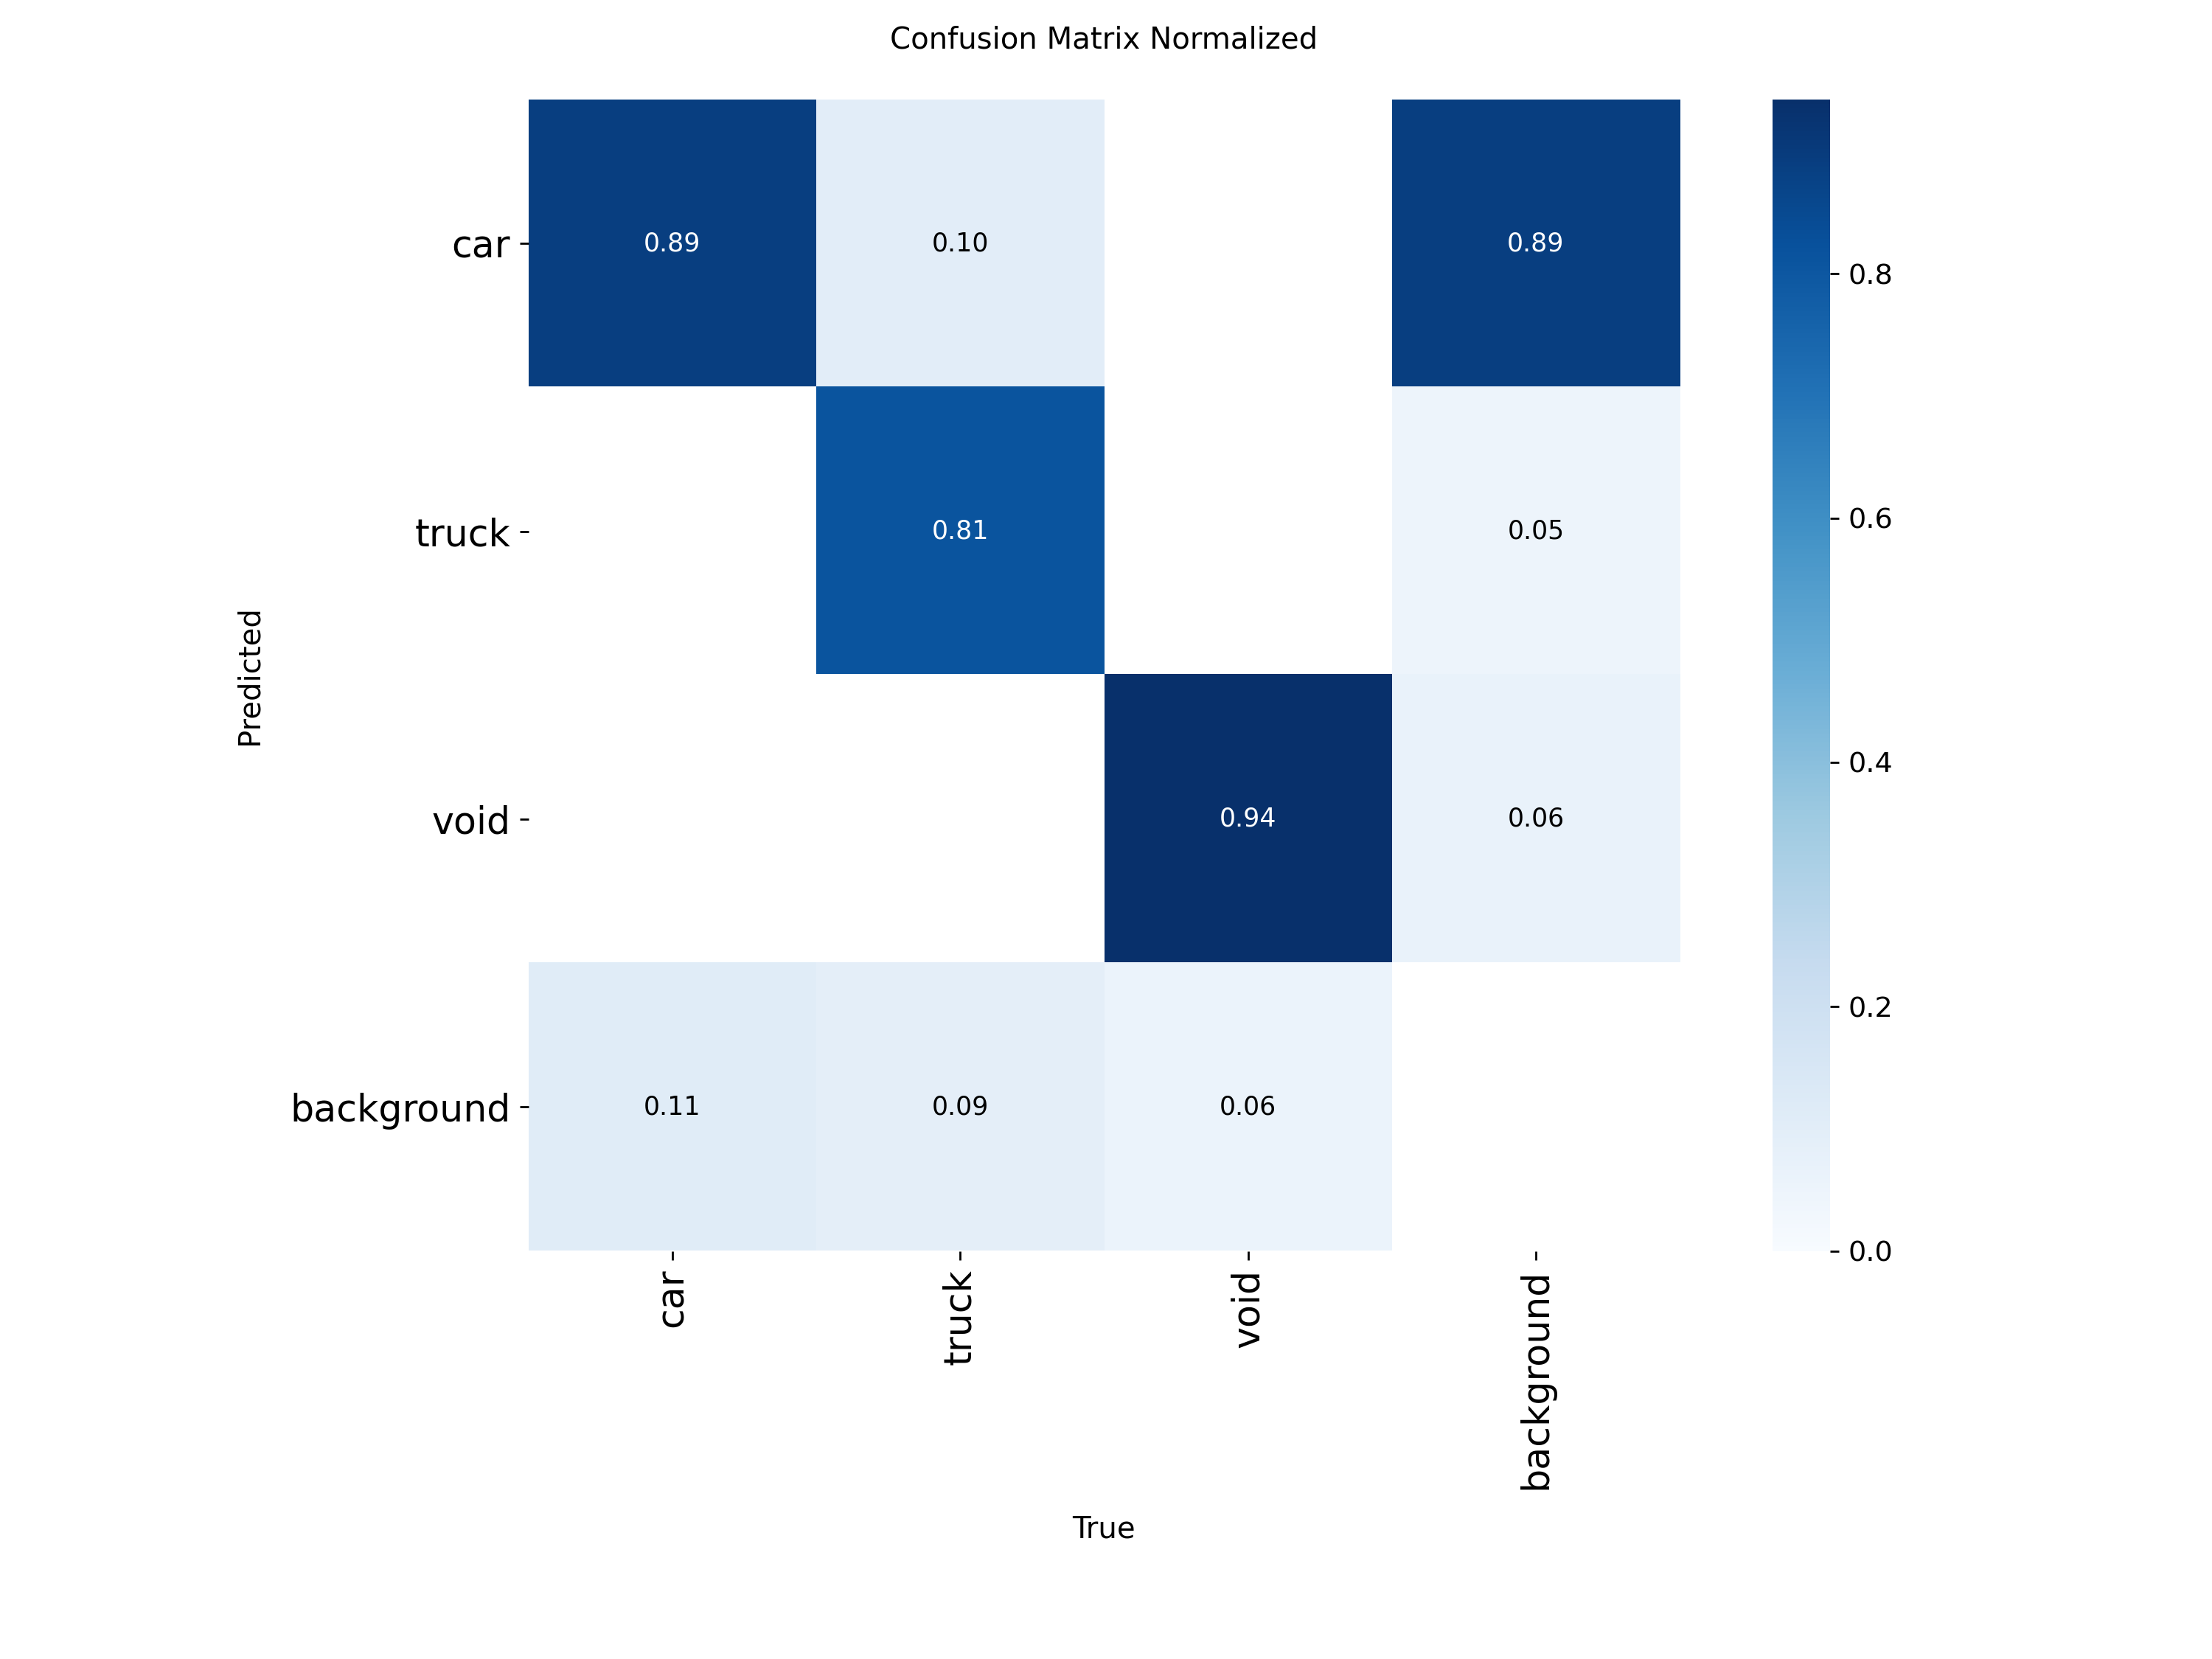

In [16]:
valid_df = results_df.dropna(subset=["mAP50"]).copy()

if len(valid_df) > 0:
    best_row = valid_df.iloc[0]

    display(Markdown(
        f"""
### Best Run
- **Run:** {best_row['Run']}
- **mAP50:** {best_row['mAP50']:.4f}
- **Precision:** {best_row['Precision']:.4f}
- **Recall:** {best_row['Recall']:.4f}
- **F1 Score:** {best_row['F1 Score']:.4f}
        """
    ))

    if best_row["Confusion Matrix"] and os.path.exists(best_row["Confusion Matrix"]):
        display(Image(filename=best_row["Confusion Matrix"]))
    else:
        print("Confusion matrix image not found for the best run.")
else:
    print("No validated runs found.")


Run: yolo26s_setup_C


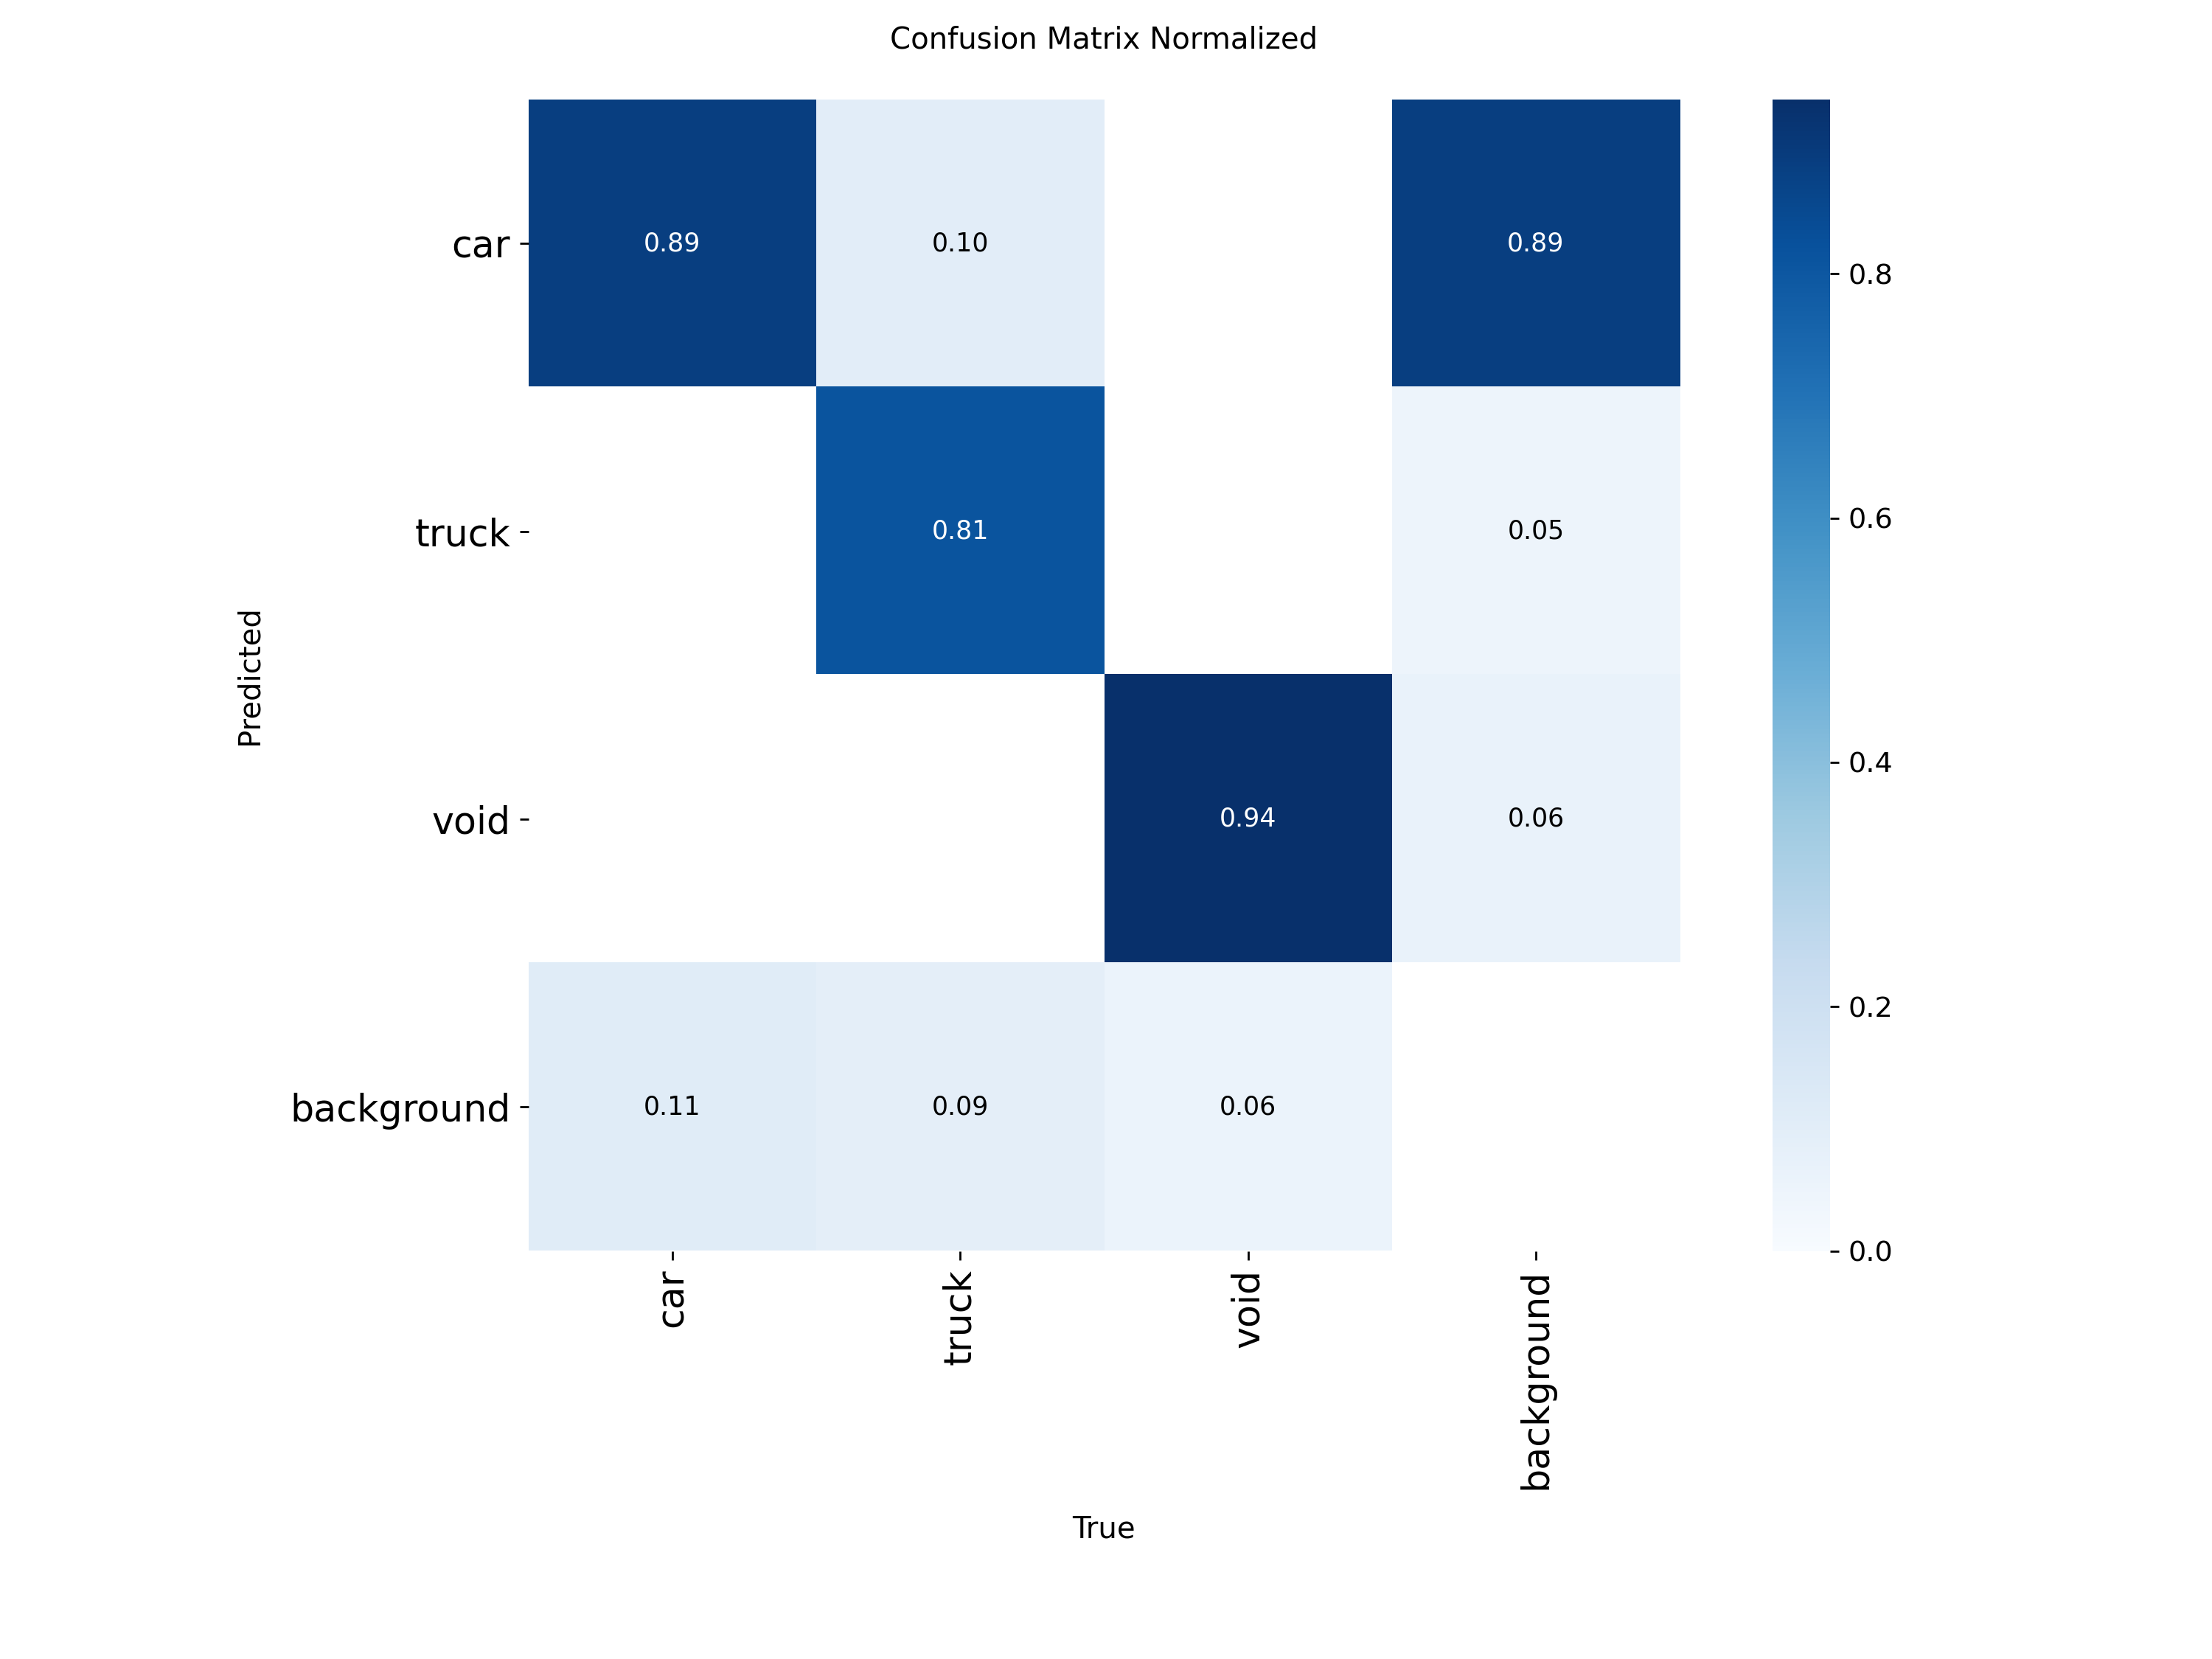


Run: yolo26m_setup_C


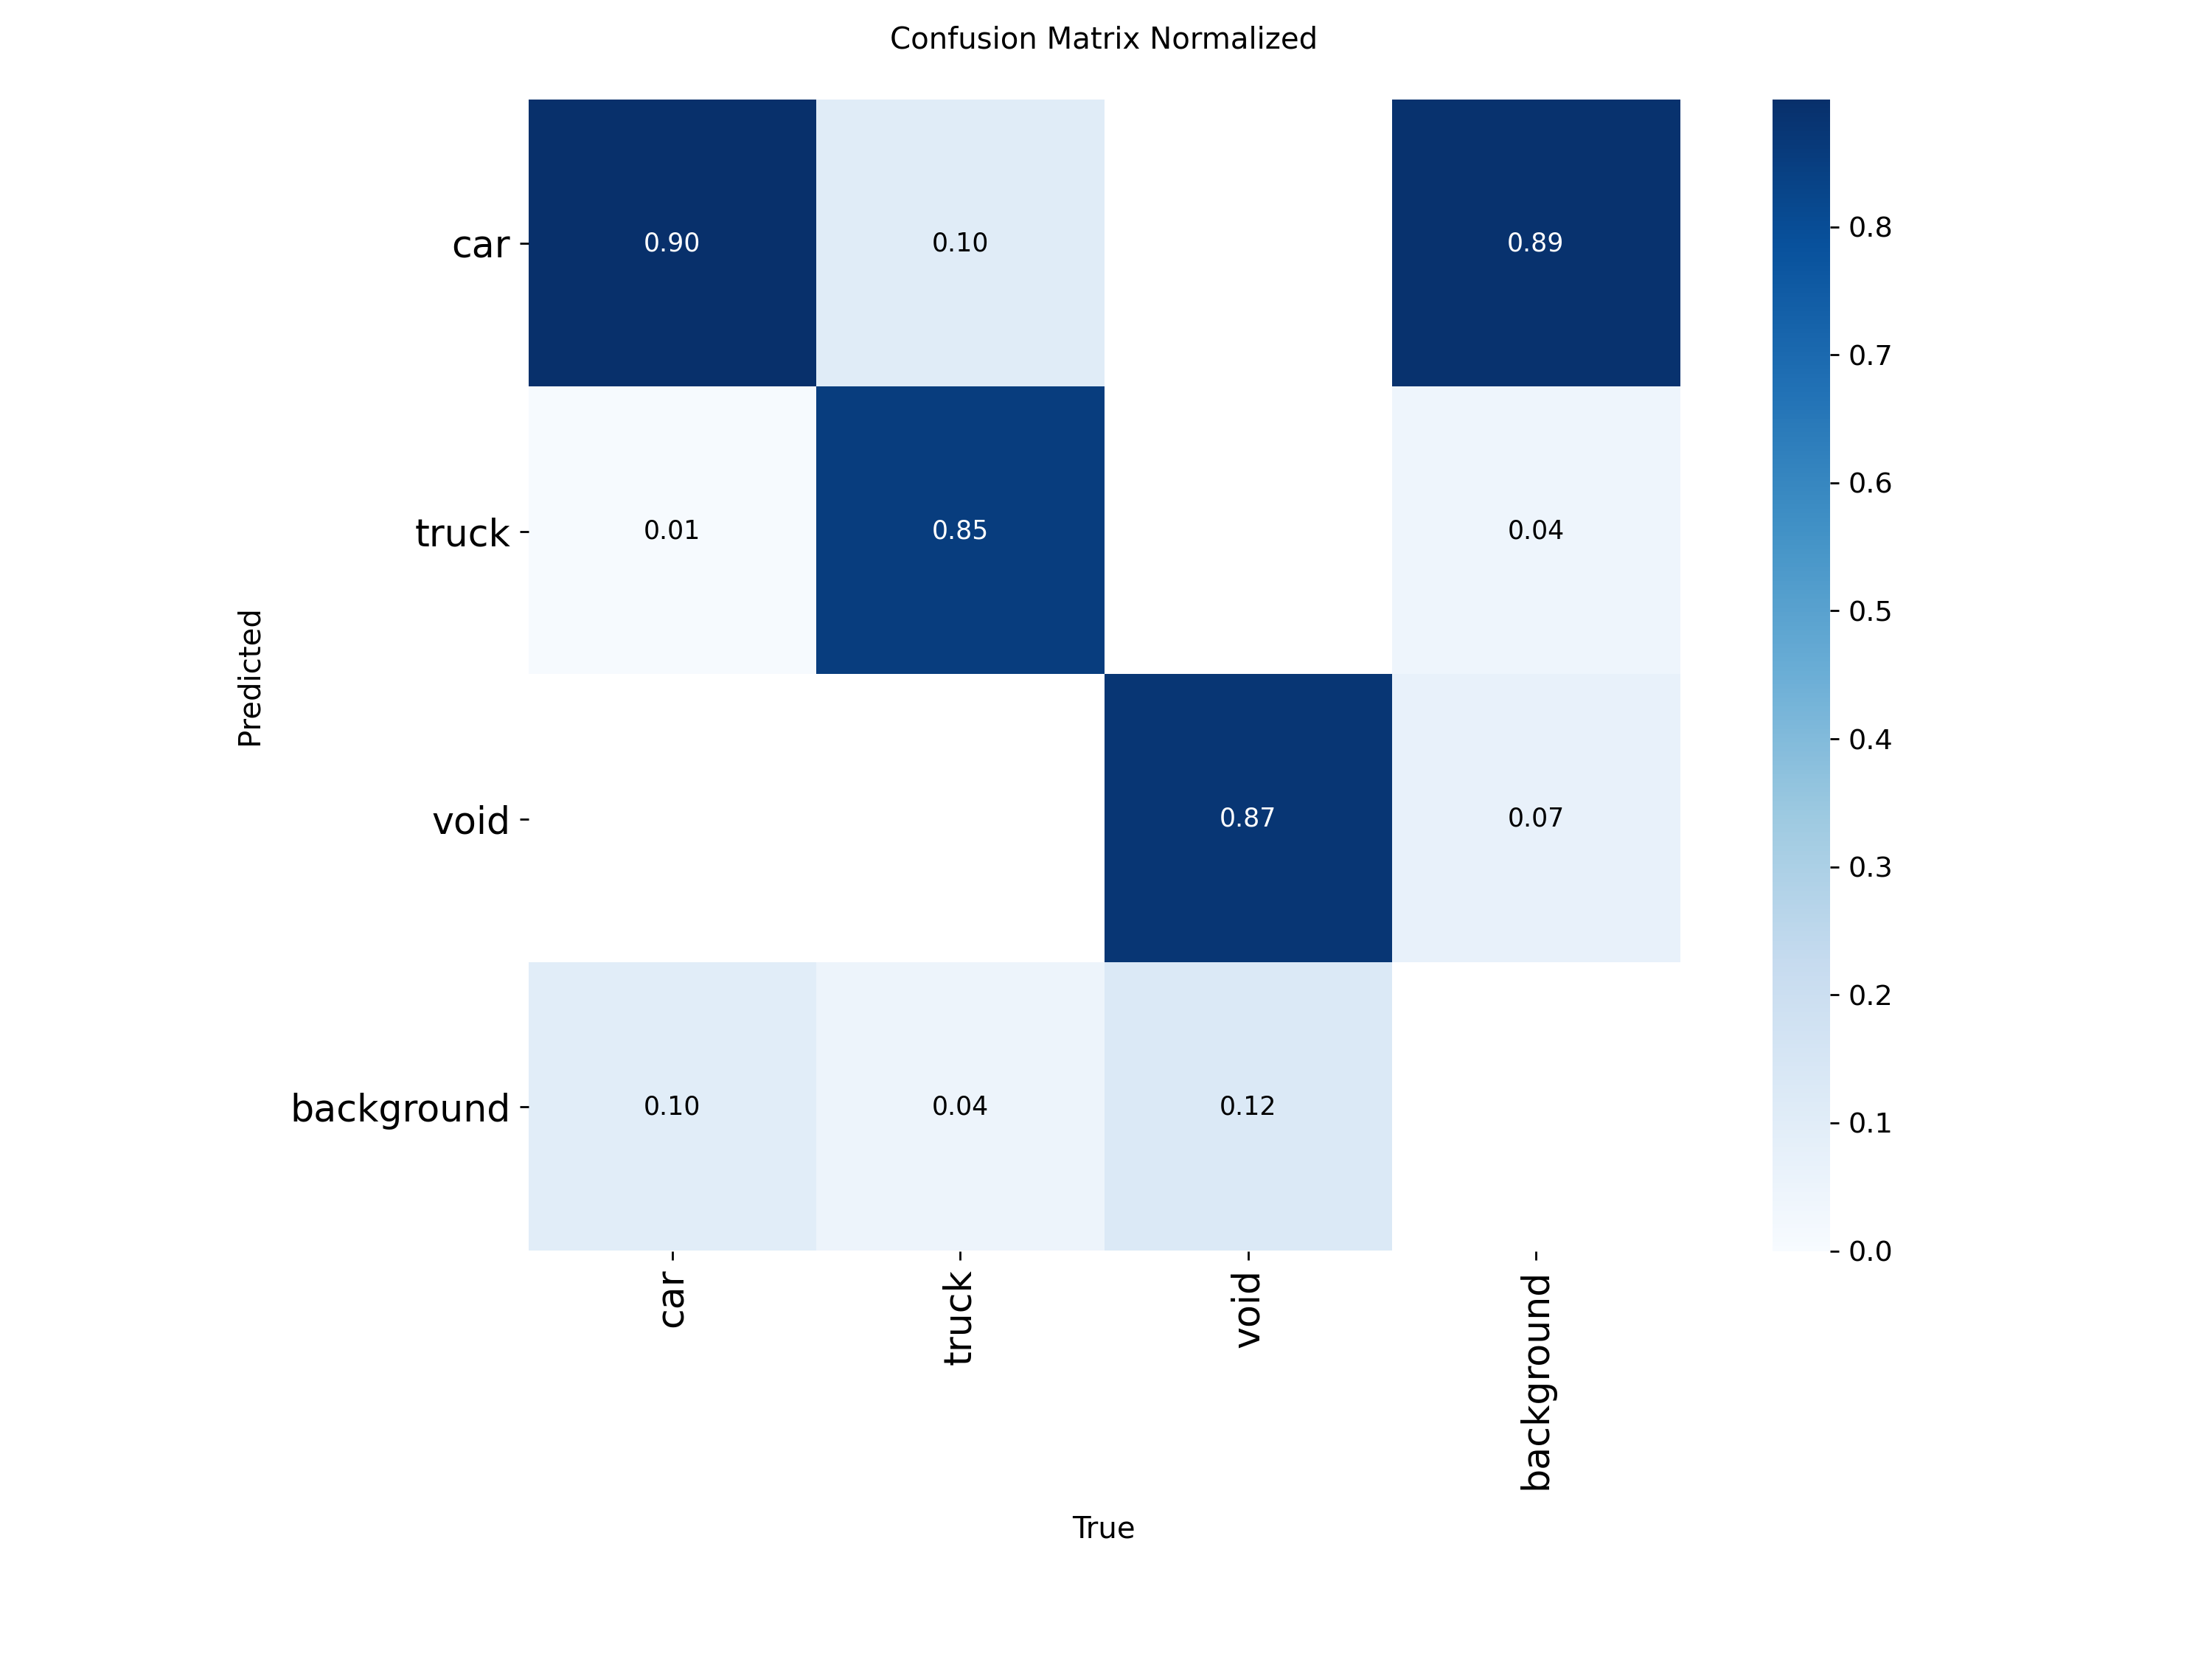


Run: yolo26s_setup_B


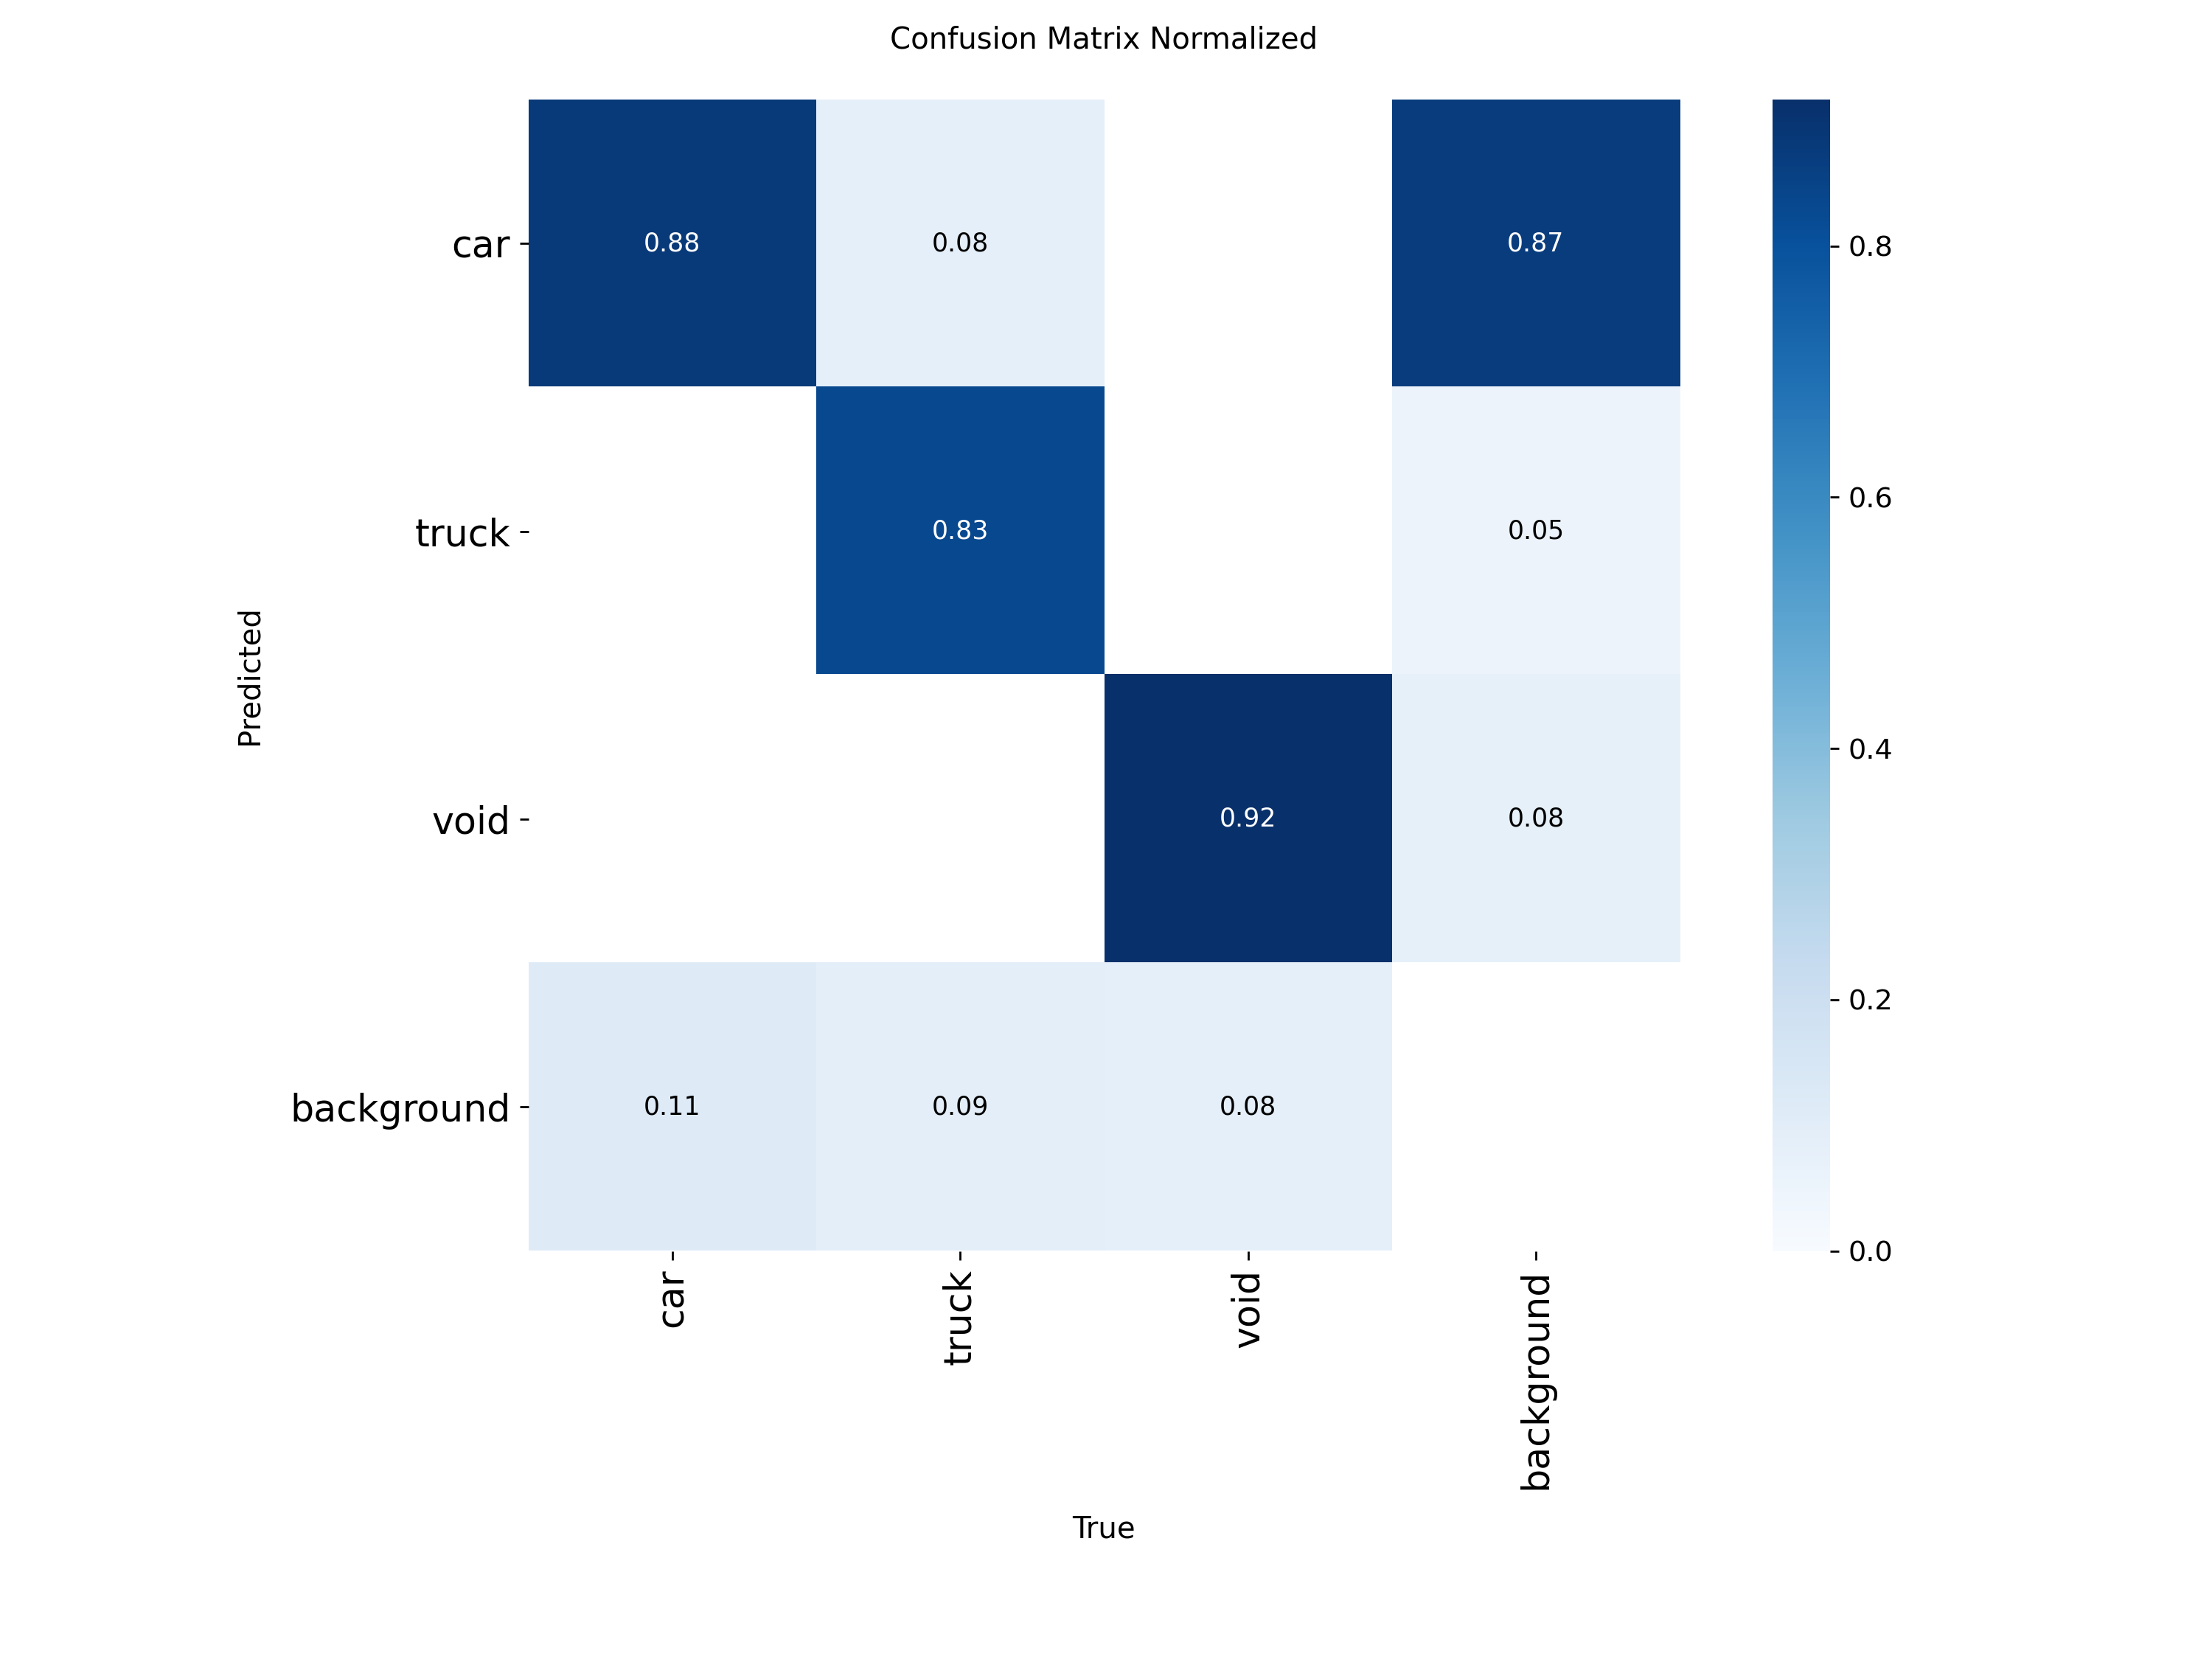


Run: yolo26m_setup_B


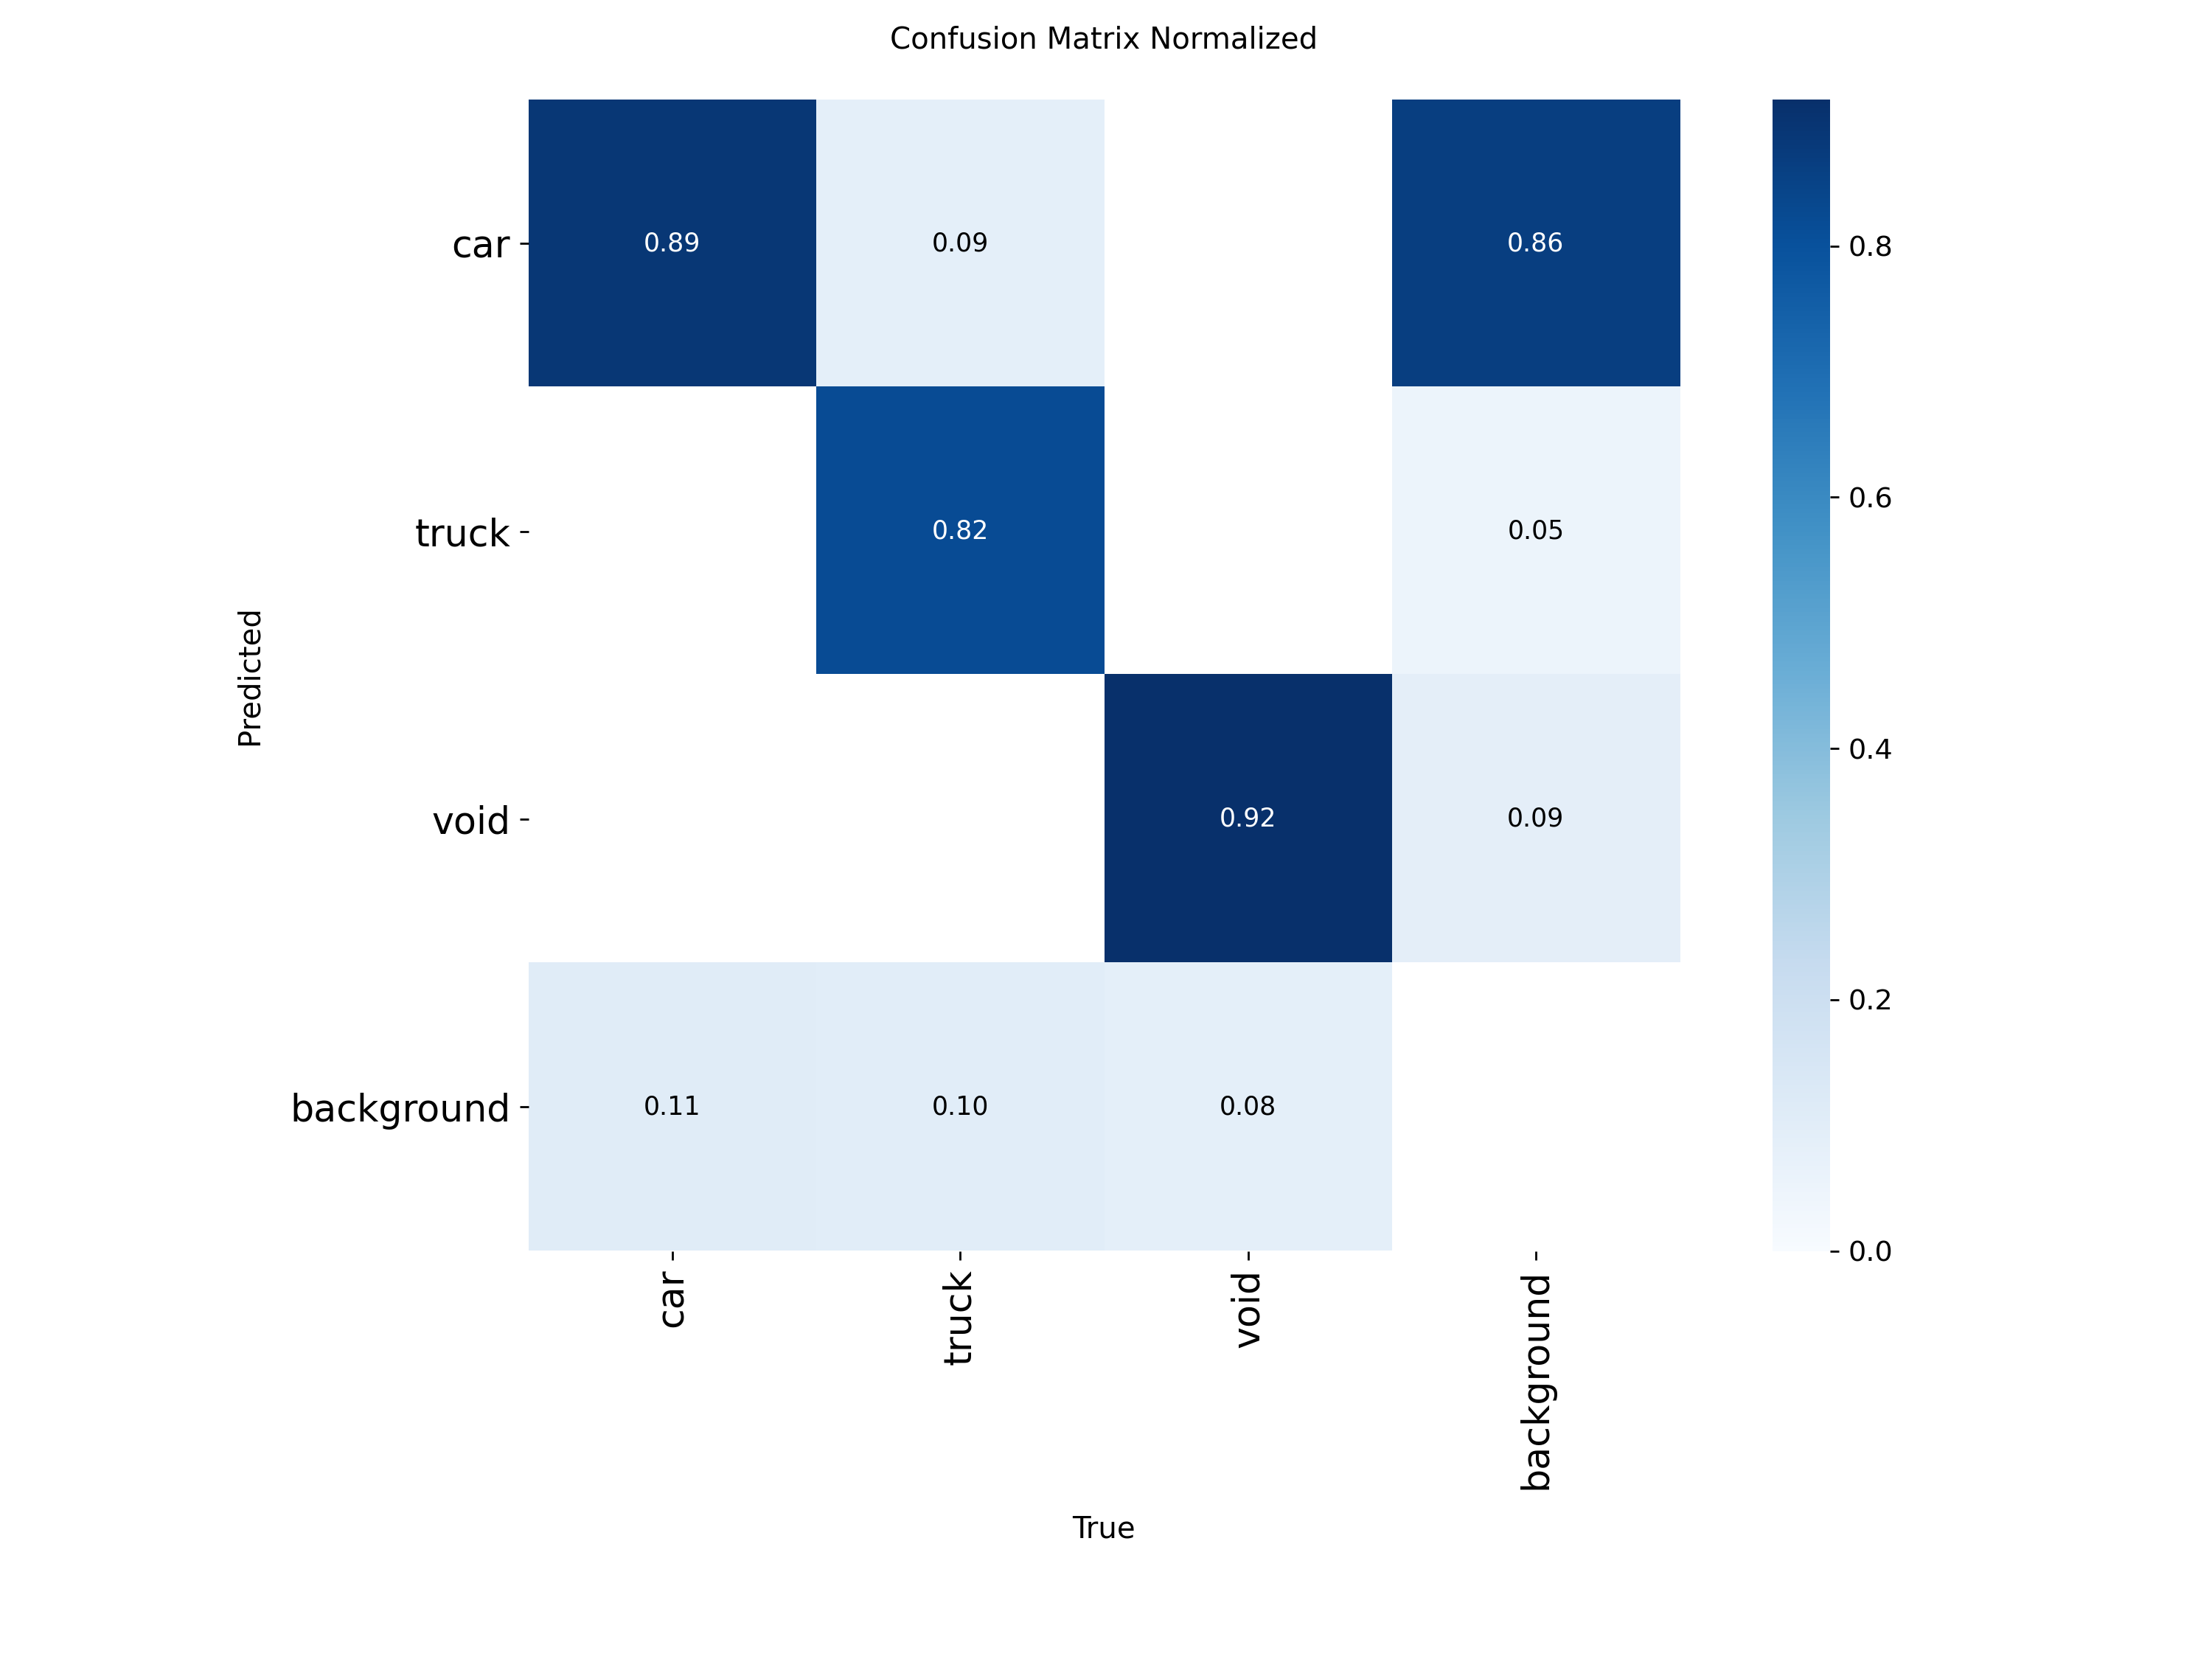


Run: yolo26s_setup_A


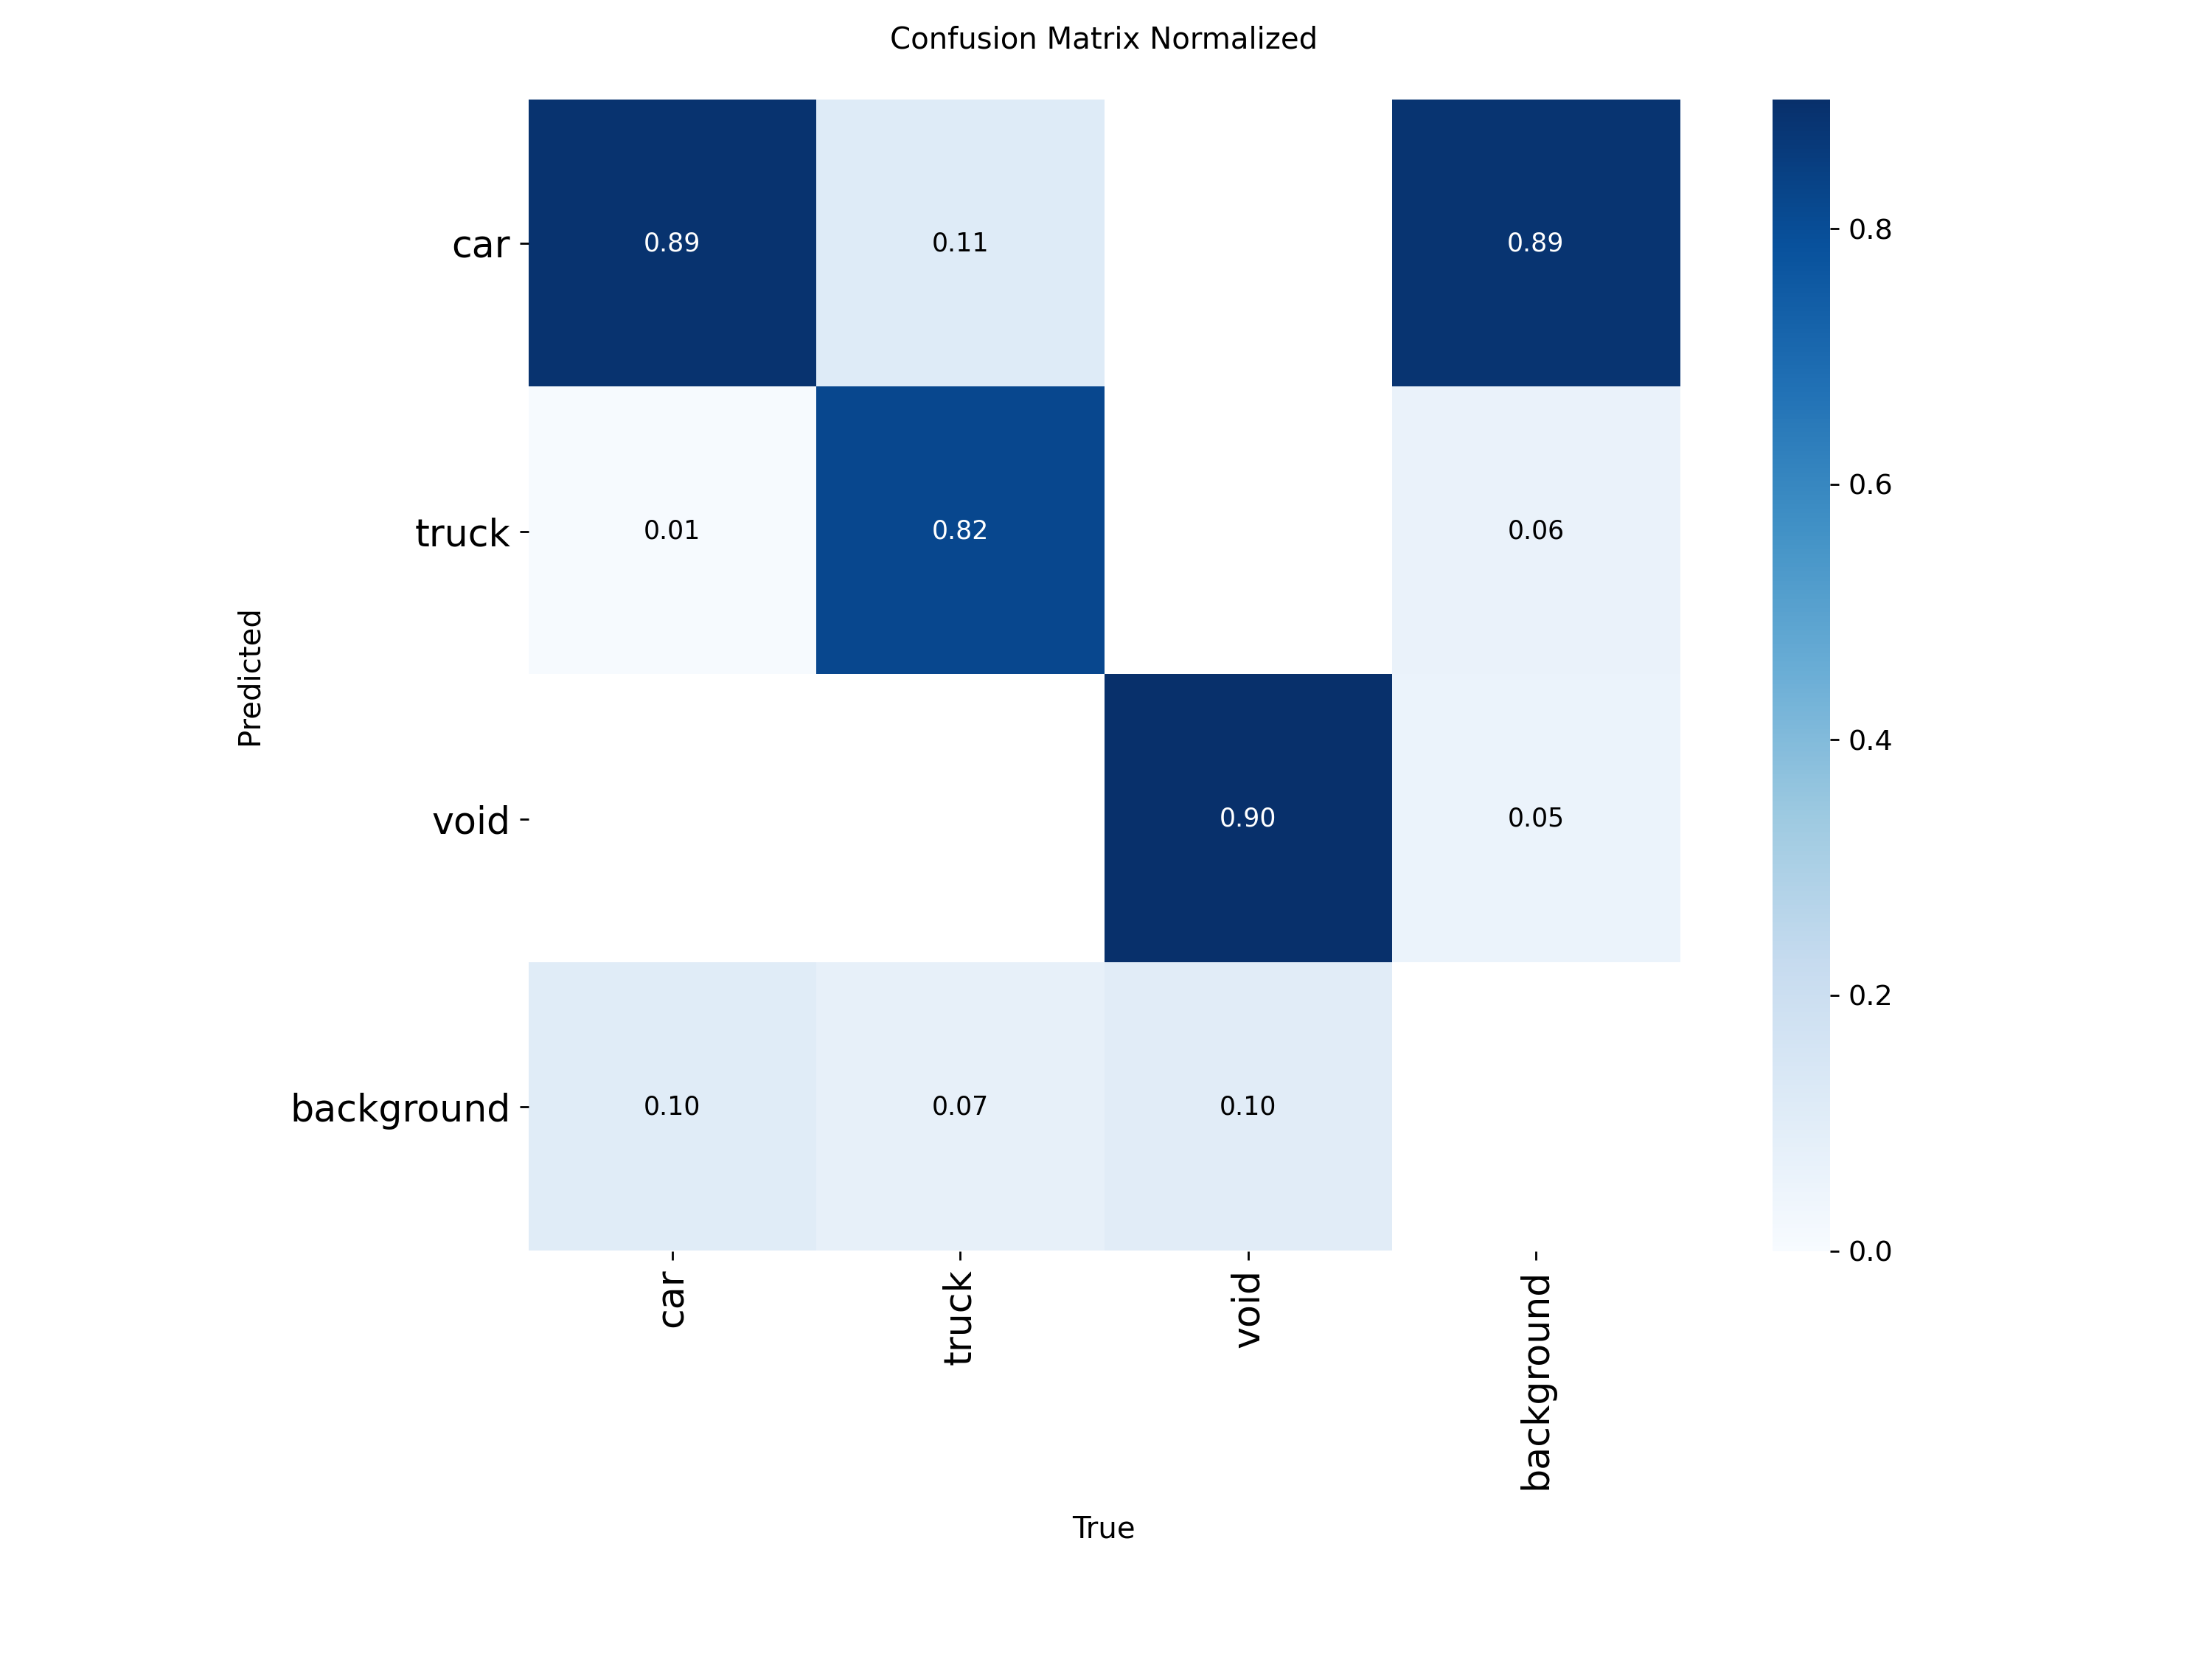


Run: yolo26m_setup_A


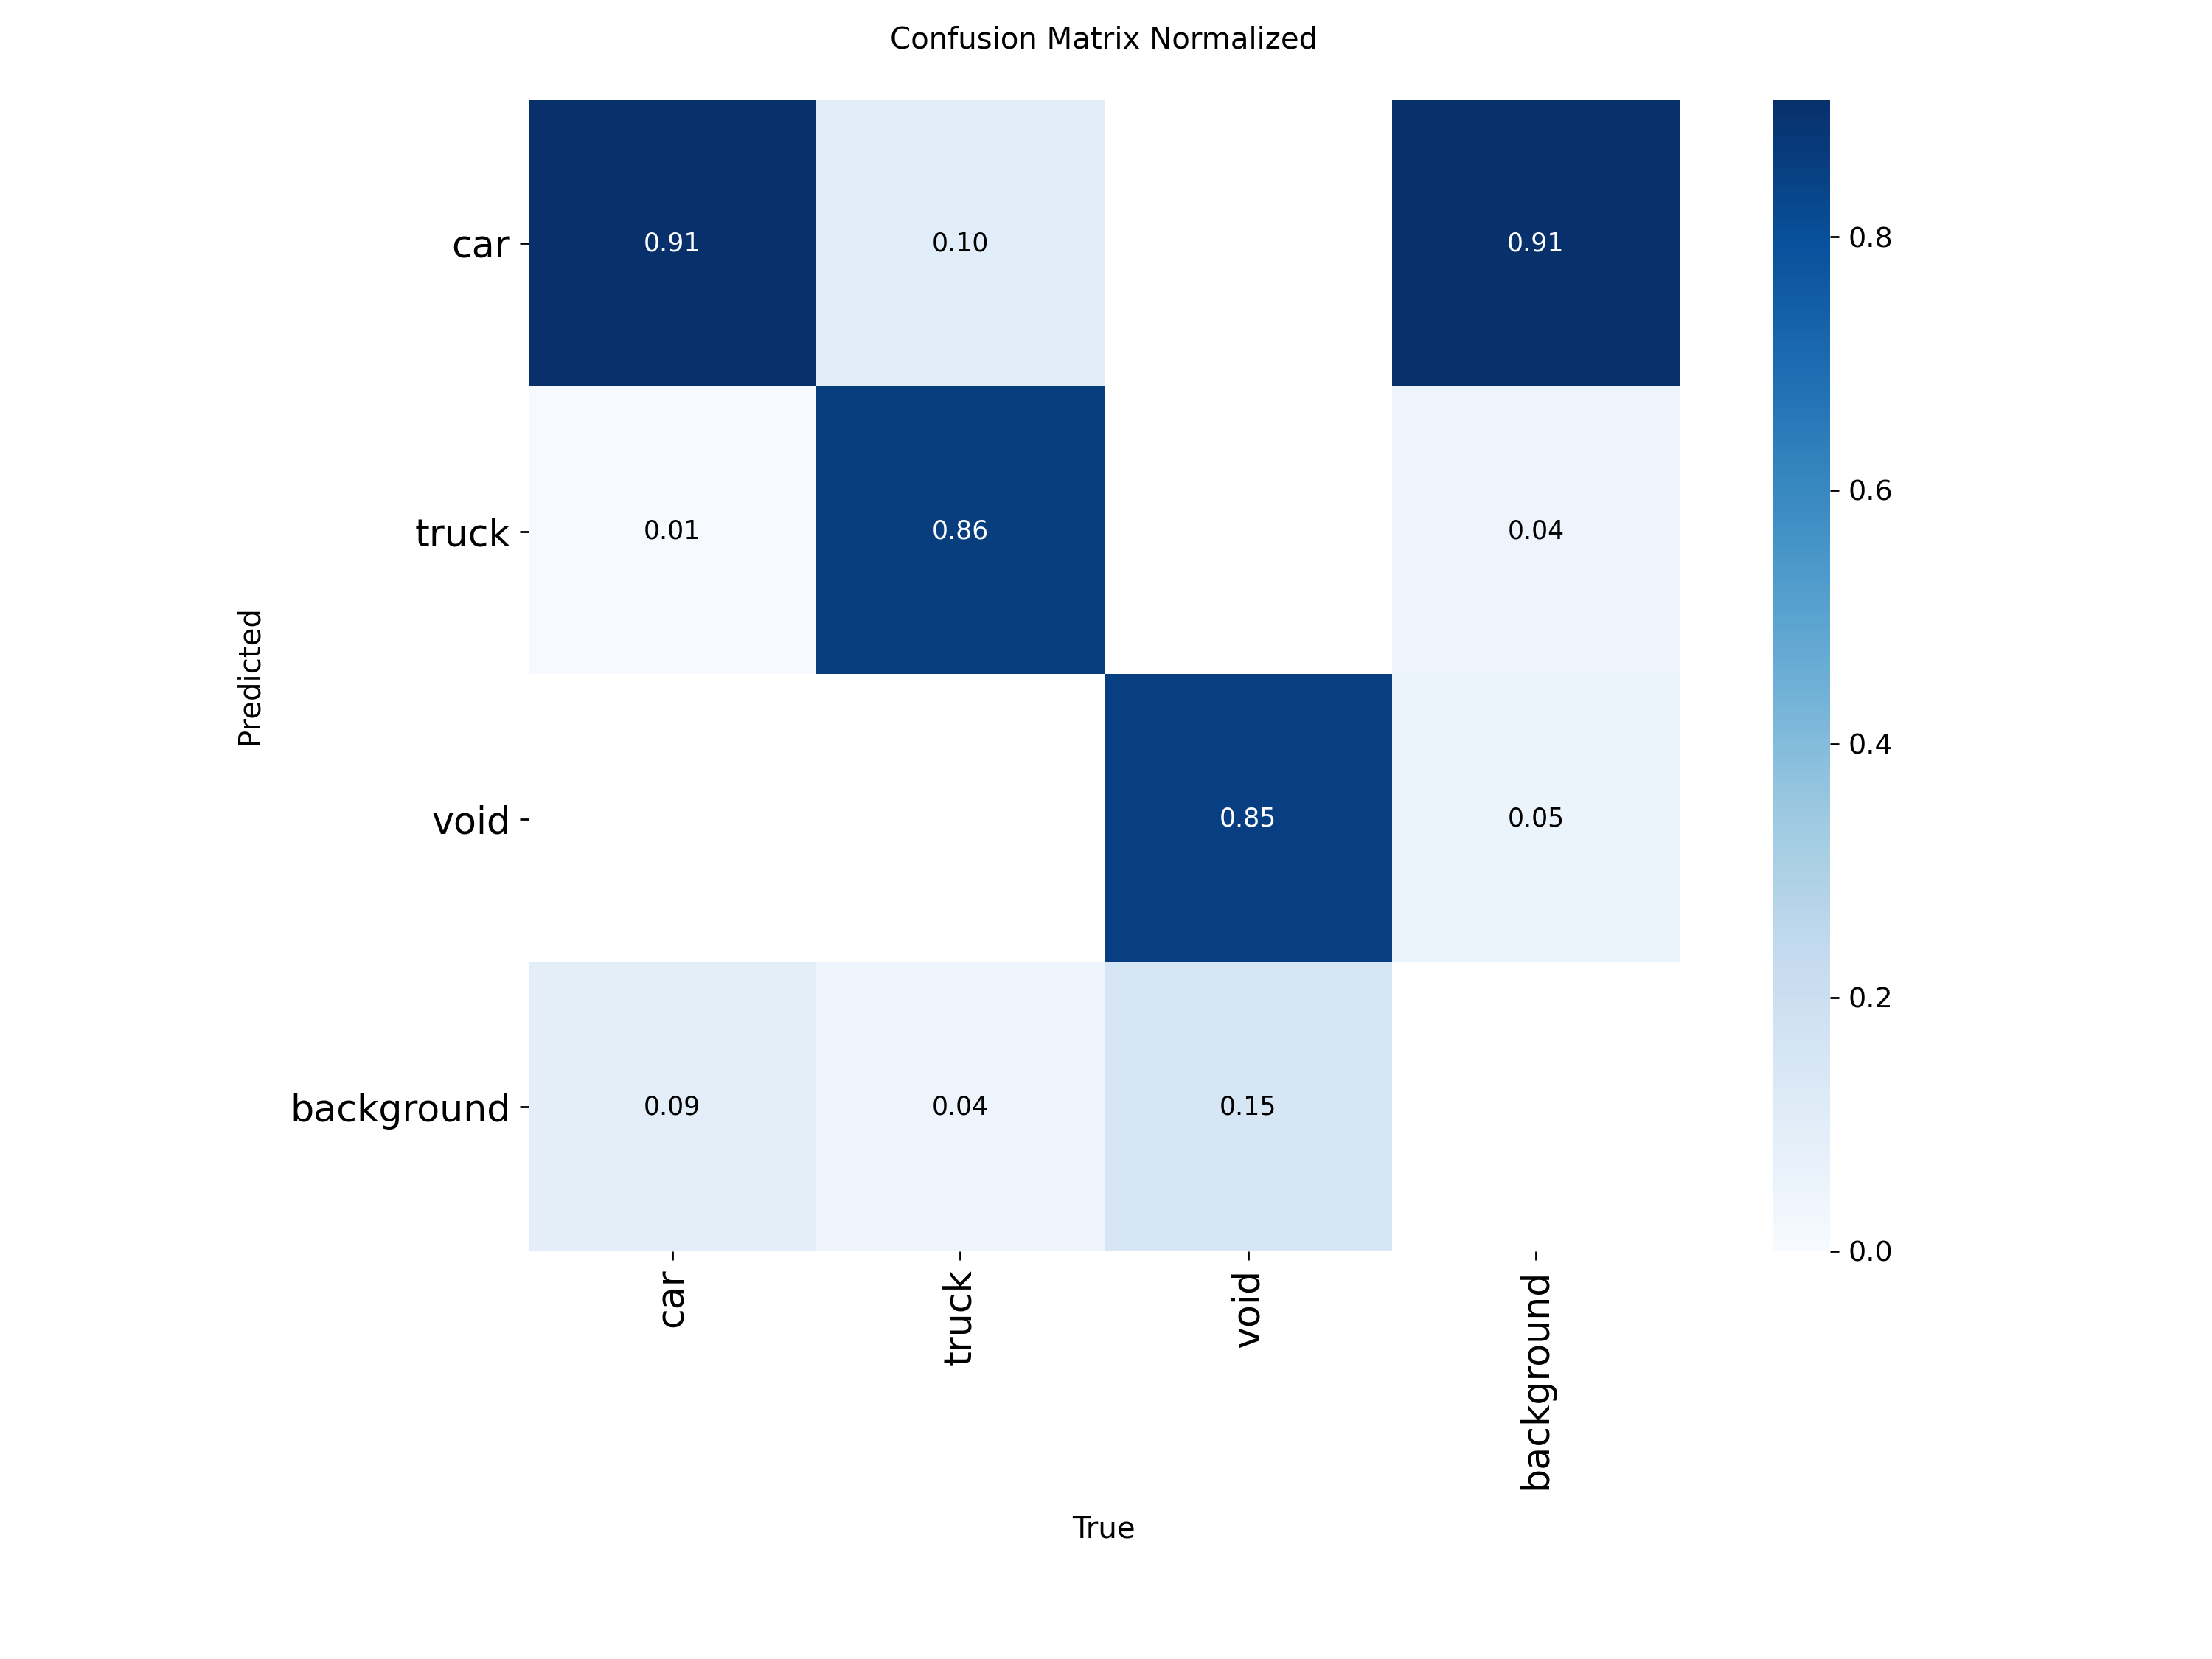


Run: yolo26n_setup_C


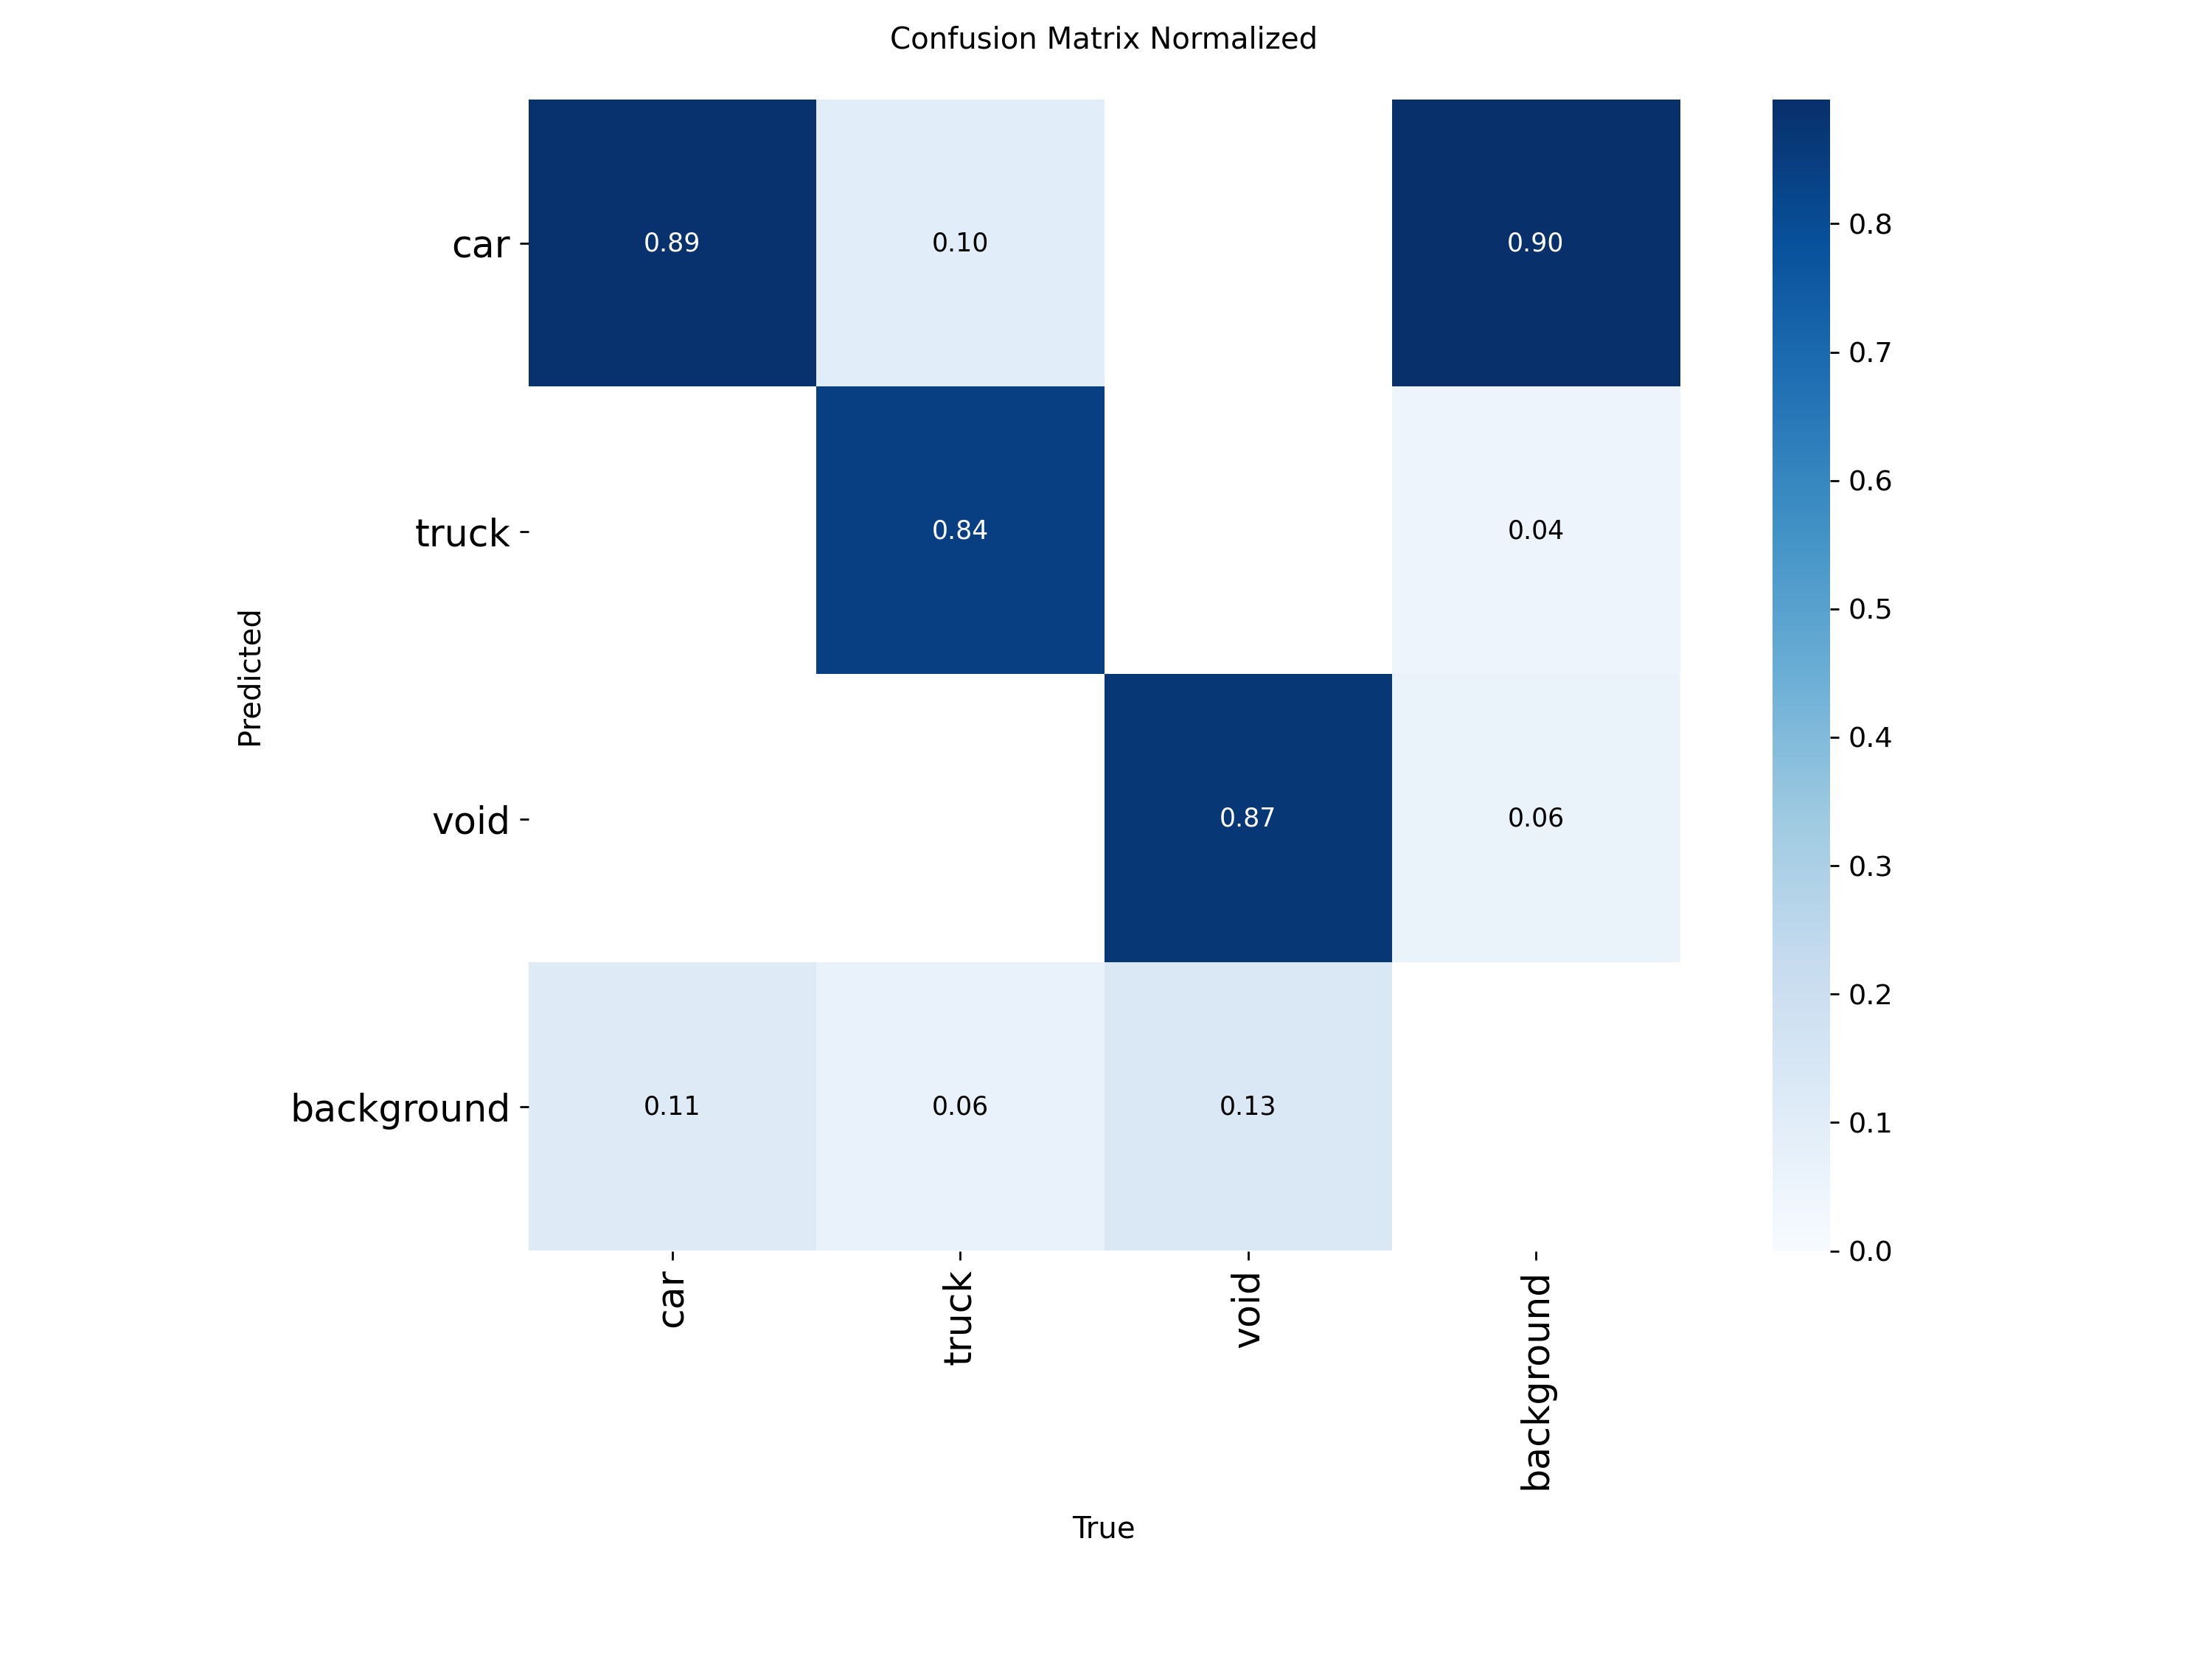


Run: yolo26n_setup_B


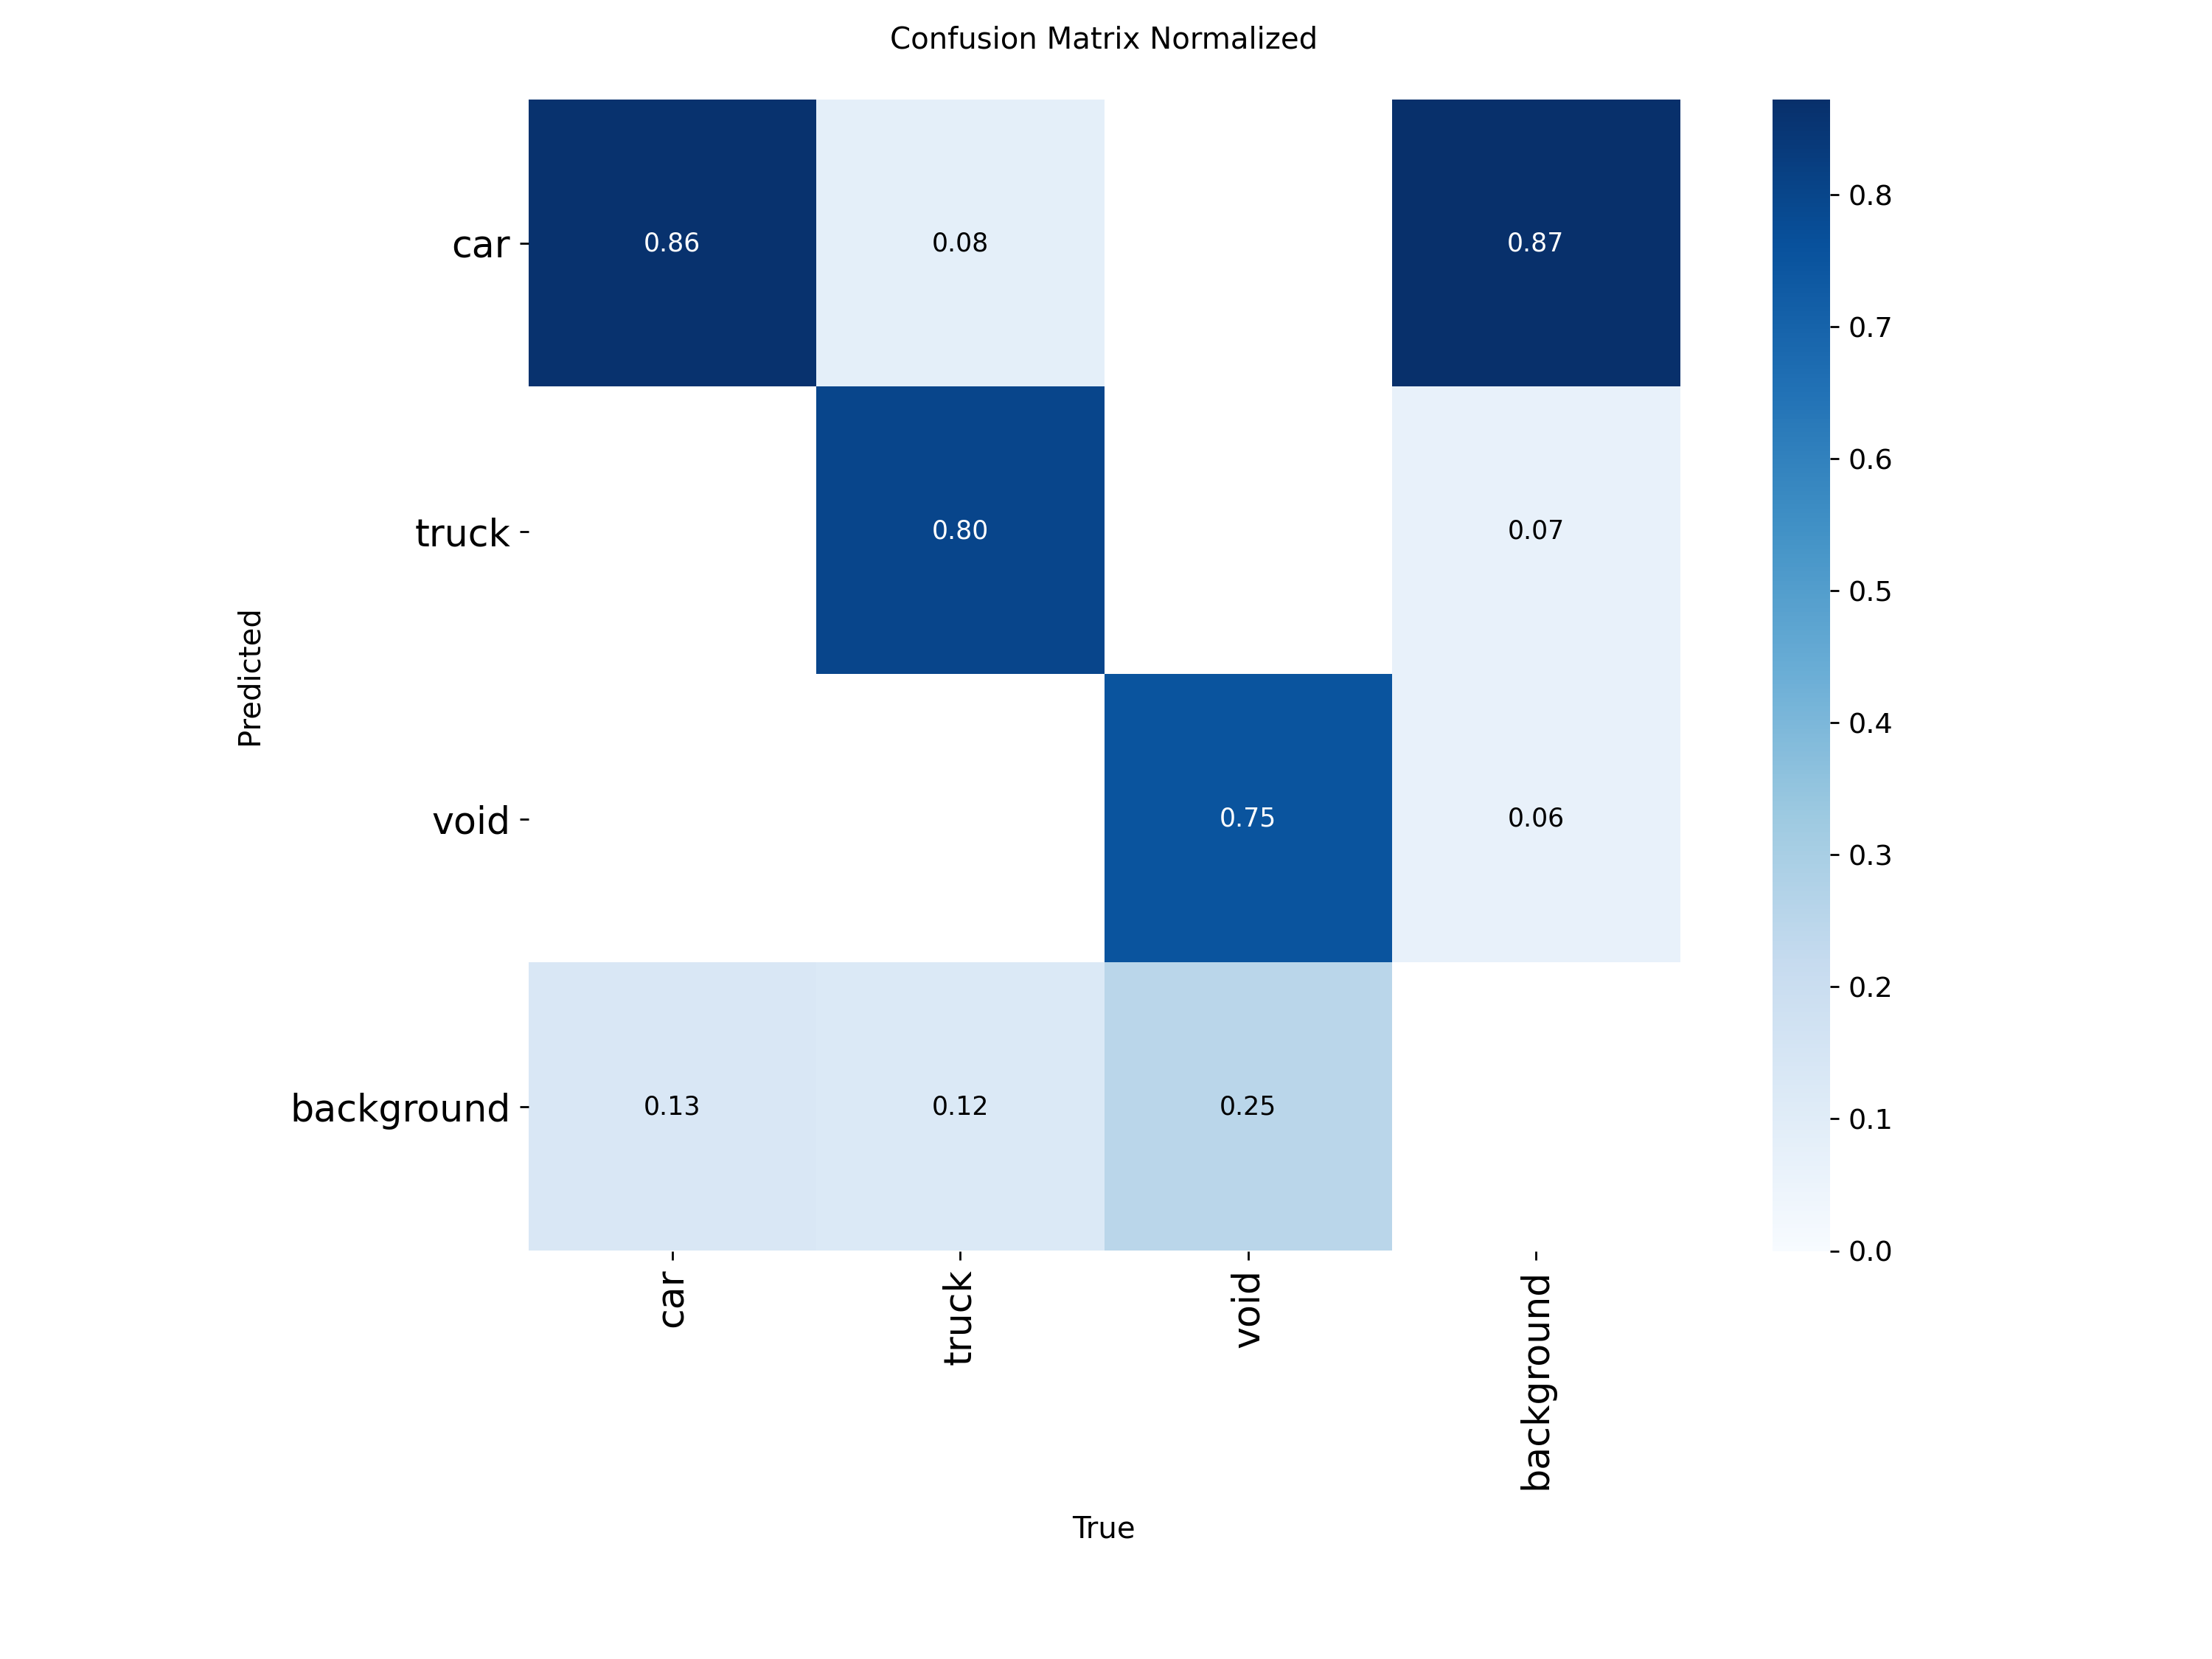


Run: yolo26n_setup_A


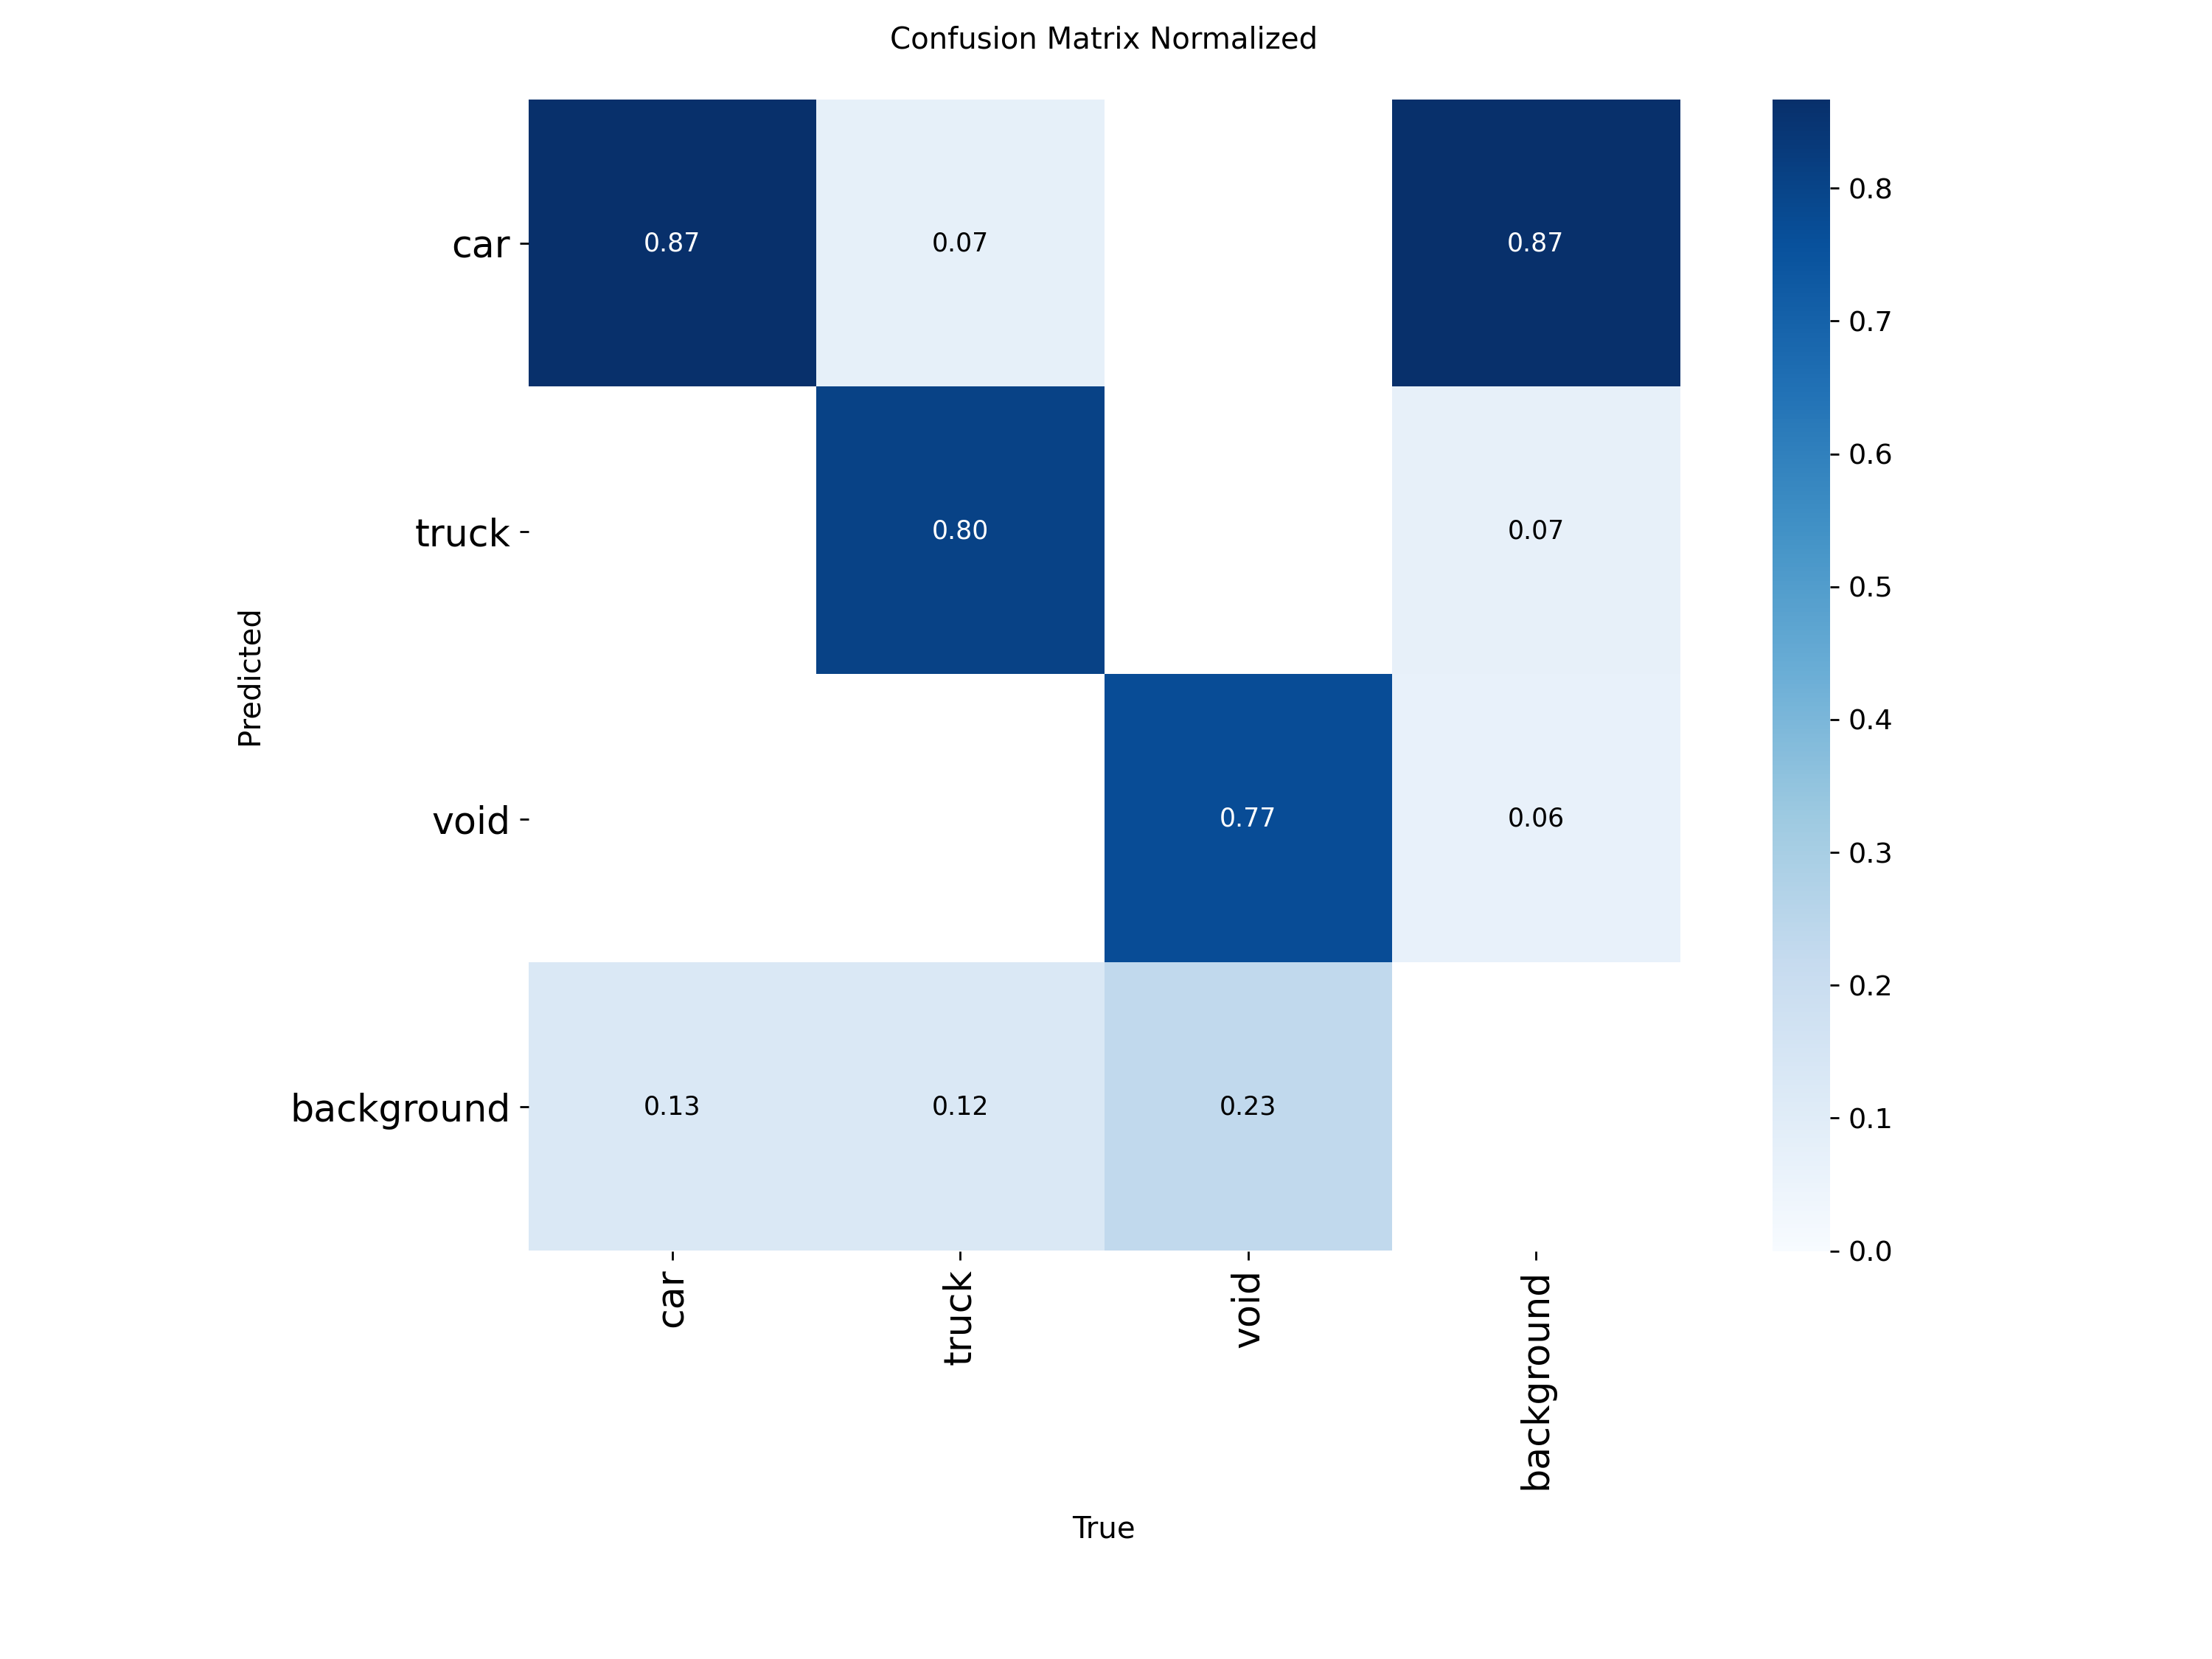

In [17]:
for _, row in results_df.iterrows():
    cm_path = row["Confusion Matrix"]
    print(f"\nRun: {row['Run']}")
    if cm_path and os.path.exists(cm_path):
        display(Image(filename=cm_path))
    else:
        print("No confusion matrix found.")

This study used the Ultralytics YOLO26 object detection framework in a Google Colab environment, with Google Drive mounted to store the dataset and training outputs. Three YOLO26 detection variants—yolo26n.pt, yolo26s.pt, and yolo26m.pt—were trained on the custom dataset using three different parameter configurations: (1) 25 epochs, image size 640, AdamW optimizer, batch size 4, and learning rate 0.001; (2) 30 epochs, image size 640, SGD optimizer, batch size 20, and learning rate 0.01; and (3) 40 epochs, image size 640, automatic optimizer selection, auto-batching (batch=-1), and learning rate 0.0001.

Initially, the initial estimate of time required to complete model training was very short; however, it became clear that a significant amount of time would actually elapse as several variations of model and parameters were being tested/validated. Despite this delay in completing model training, experimentation could still be completed with the help of Google Colab, because the computing resources available on that cloud platform were sufficient to run through all models/configurations (whether it was a large or small variation of both) within a single day. Once all models had completed training (including enough samples to build a valid training data set), performance metrics such as mean average precision (mAP50), Precision and Recall of each model could be recorded via the built-in Ultralytics validation module. Next, the Precision and Recall of each model were used to calculate the F1 Score from both Precision and Recall values. Additionally, the confusion matrix associated with each validation trial was evaluated for the presence of true positives on the main diagonal, as well as background false positives associated with non-target objects (e.g., visually similar objects to the target object) that would suggest a lack of ability to differentiate between visually similar non-target objects and the target object. Finally, based upon the interpretation of these combined statistical performances and diagnostic metrics/output, the readyneness of the model for potential deployment against real-world situations was assessed.


